# Domain A: Transcriptomic Identity and Neural Coding

This notebook addresses three questions:
- **A1:** Do transcriptomically defined cell types have distinct tuning properties?
- **A2:** Does gene expression predict functional response properties at the single-cell level?
- **A3:** How does transcriptomic identity shape population coding geometry?

**Data:** Zarr multimodal stores with ΔF/F calcium traces (X matrix, cells × trials), stimulus metadata (var), cell-type labels & gene expression (obs).

In [5]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
from types import SimpleNamespace
from scipy.optimize import curve_fit
from scipy.stats import kruskal, mannwhitneyu, spearmanr, pearsonr
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.decomposition import PCA, NMF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from pathlib import Path    
from matplotlib import cm, colors
import warnings
import anndata as ad
warnings.filterwarnings('ignore')

from functions.data_loading import load_mouse_zarr, zarr_to_df
from functions.visualization import polar_bar_plot


from functions.constants import (
    SUBCLASS_ORDER, SUBCLASS_COLORS, SUBCLASS_SHORT,
    SUPERTYPE_ORDER, SUPERTYPE_COLORS, SUPERTYPE_SHORT,
    SUPERTYPE_TO_SUBCLASS, SUBCLASS_SUPERTYPES
)

sns.set_context('talk')
sns.set_style('whitegrid')


In [2]:
# ══════════════════════════════════════════════════════════════════════
# Load data from zarr DATA_DIR stores
# ══════════════════════════════════════════════════════════════════════
DATA_DIR = Path('/root/capsule/data')
SCRATCH_DIR = Path('/root/capsule/scratch')
FIG_DIR = SCRATCH_DIR / 'Analysis_figures/Domain_A_Transcriptomic_Function/01_cell-type-specific-tuning-properties'
FIG_DIR.mkdir(parents=True, exist_ok=True)
MOUSE_IDS = ['_'.join(f.stem.split('_')[1:3]) for f in DATA_DIR.glob('multimodal*')]
SESSIONS = ['session_1', 'session_2', 'session_3']

session_type = ['drifting_gratings']
MOUSE_IDS

['h_755252',
 'x_778174',
 'h_782149',
 'x_786297',
 'h_790322',
 'h_767022',
 'x_797371',
 'h_788406',
 'h_767018']

In [3]:
mouse_file_map = {}
for mid in MOUSE_IDS:
    h5_matches = sorted(DATA_DIR.glob(f'multimodal_{mid}*/multimodal_avg_{mid}.h5ad'))
    zarr_matches = sorted(DATA_DIR.glob(f'multimodal_{mid}*/multimodal_{mid}.zarr'))
    mouse_file_map[mid] = {
        'h5ad': h5_matches[0] if len(h5_matches) else None,
        'zarr': zarr_matches[0] if len(zarr_matches) else None,
    }

pd.DataFrame(mouse_file_map).T

,h5ad,zarr
h_755252,/root/capsule/data/multimodal_h_755252_2026-04...,/root/capsule/data/multimodal_h_755252_2026-04...
x_778174,/root/capsule/data/multimodal_x_778174_2026-04...,/root/capsule/data/multimodal_x_778174_2026-04...
h_782149,/root/capsule/data/multimodal_h_782149_2026-04...,/root/capsule/data/multimodal_h_782149_2026-04...
x_786297,/root/capsule/data/multimodal_x_786297_2026-04...,/root/capsule/data/multimodal_x_786297_2026-04...
h_790322,/root/capsule/data/multimodal_h_790322_2026-04...,/root/capsule/data/multimodal_h_790322_2026-04...
h_767022,/root/capsule/data/multimodal_h_767022_2026-04...,/root/capsule/data/multimodal_h_767022_2026-04...
x_797371,/root/capsule/data/multimodal_x_797371_2026-04...,/root/capsule/data/multimodal_x_797371_2026-04...
h_788406,/root/capsule/data/multimodal_h_788406_2026-04...,/root/capsule/data/multimodal_h_788406_2026-04...
h_767018,/root/capsule/data/multimodal_h_767018_2026-04...,/root/capsule/data/multimodal_h_767018_2026-04...


In [4]:
merged_cell_info = {}
for mid in MOUSE_IDS:
    if not mid.startswith('x'):
        continue
    zarr_path = mouse_file_map[mid]['zarr']
    z = zarr.open(str(zarr_path), mode='r')
    unique_ids = z['unique_id'][:]
    cellxgene_df = zarr_to_df(z['transcriptomics/cellxgene'])
    cell_type_df = zarr_to_df(z['transcriptomics/cell_type'])
    morphology_df = zarr_to_df(z['morphology/mask_properties'])
    merged_cells_df = pd.concat([cellxgene_df, cell_type_df, morphology_df], axis=1)
    
    pca = PCA(n_components=5, random_state=0)
    pca.fit(cellxgene_df.values)
    pcs = pca.transform(cellxgene_df.values)
    for k in range(pcs.shape[1]):
        merged_cells_df[f'pca_all_{k+1}'] = pcs[:, k]
    
    if mid.startswith('h'):
        merged_cells_df[f'pca_glut_{k+1}'] = np.nan
        merged_cells_df[f'pca_gaba_{k+1}'] = merged_cells_df[f'pca_all_{k+1}']
        continue
    glut_cells = merged_cells_df[merged_cells_df['subclass_name'].str.contains('Glut')].index.values

    cellxgene_glut = cellxgene_df.loc[glut_cells].values
    pca_glut = PCA(n_components=5, random_state=0)
    pca_glut.fit(cellxgene_glut)
    pcs_glut = pca_glut.transform(cellxgene_df.values)
    for k in range(pcs_glut.shape[1]):
        merged_cells_df[f'pca_glut_{k+1}'] = pcs_glut[:, k]

    gaba_cells = merged_cells_df[merged_cells_df['subclass_name'].str.contains('Gaba')].index.values
    cellxgene_gaba = cellxgene_df.loc[gaba_cells].values
    pca_gaba = PCA(n_components=5, random_state=0)
    pca_gaba.fit(cellxgene_gaba)
    pcs_gaba = pca_gaba.transform(cellxgene_df.values)
    for k in range(pcs_gaba.shape[1]):
        merged_cells_df[f'pca_gaba_{k+1}'] = pcs_gaba[:, k]

    merged_cell_info[mid] = merged_cells_df
    

In [10]:
SESSIONS = ['session_1', 'session_2', 'session_3']

for mid in MOUSE_IDS:
    ad_path = list(list(DATA_DIR.glob(f"multimodal_{mid}*"))[0].glob('*.h5ad'))[0]
    zarr_path = list(list(DATA_DIR.glob(f"multimodal_{mid}*"))[0].glob('*.zarr'))[0]
    adata = ad.read_h5ad(ad_path)

    cells_obs = adata.obs
    trial_info = adata.var

    subclasses = cells_obs['subclass_name'].unique()
    for subclass in subclasses:
        mask_cells = cells_obs['subclass_name'] == subclass  # Example: select one subclass

        
        # Plotting
        fig, axs = plt.subplots(2, 3, figsize=(30, 20))

        dff_avg = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.asarray(adata.X)
        dff_baseline = adata.layers['baseline']
        dff_baseline = dff_baseline.toarray() if hasattr(dff_baseline, 'toarray') else np.asarray(dff_baseline)
        dff_avg = dff_avg - dff_baseline  # Baseline correction
        dff_avg_zscore = (dff_avg - np.nanmean(dff_avg, axis=1, keepdims=True)) / np.nanstd(dff_avg, axis=1, keepdims=True)

        orientations = np.array([0, 45, 90, 135, 180, 225, 270, 315])
        unique_tf_contrasts = trial_info[['temporal_frequency', 'contrast']].drop_duplicates().sort_values(by=['temporal_frequency', 'contrast']).values

        cell_idx = np.where(mask_cells.values)[0]
        days = np.sort(trial_info['day'].unique())
        for i_day, day in enumerate(days):
            mask_day = trial_info['day'] == day
            print(f"Mouse {mid} — day {day} - Subclass: {subclass} — n_cells: {mask_cells.sum()}")

            resp_cube = np.full((len(cell_idx), len(unique_tf_contrasts), len(orientations)), np.nan)
  
            # Build per-cell responses for each (TF, contrast, orientation)
            for i_tf_cont, tf_contrast in enumerate(unique_tf_contrasts):
                tf, contrast = tf_contrast
                mask_tf = trial_info['temporal_frequency'] == tf
                mask_contrast = trial_info['contrast'] == contrast
                for i_ori, orientation in enumerate(orientations):
                    mask_ori = trial_info['orientation'] == orientation
                    mask_trials = mask_tf & mask_contrast & mask_ori & mask_day
                    if mask_trials.sum() == 0:
                        continue
                    resp_cube[:, i_tf_cont, i_ori] = np.nanmean(dff_avg_zscore[cell_idx][:, mask_trials], axis=1)

            pref_idx = [np.unravel_index(np.nanargmax(resp_cube[i]), resp_cube[i].shape)[1] for i in range(resp_cube.shape[0])]
            pref_ori = orientations[pref_idx]

            # Circularly shift each cell so preferred orientation is at 0°
            resp_cube_pref = np.full_like(resp_cube, np.nan)
            for i_cell in range(len(cell_idx)):
                resp_cube_pref[i_cell] = np.roll(resp_cube[i_cell], -pref_idx[i_cell], axis=1)

            # Average over cells after pref-orientation alignment
            data = np.nanmean(resp_cube_pref, axis=0)  # (n_tf_contrasts, n_orientations)
            ax = axs[0, i_day]
            for i_tf_cont, tf_contrast in enumerate(unique_tf_contrasts):
                tf, contrast = tf_contrast
                ax.plot(orientations, data[i_tf_cont], label=f'TF={tf}Hz, C={contrast}')
            ax.set_xlabel('Δ Orientation from pref (degrees)')
            ax.set_ylabel('Mean Z-scored dF/F')
            ax.set_xticks(orientations)
            ax.set_title(f'Session {day}')
            ax.legend(bbox_to_anchor=(1, 1), fontsize=9)

            ax = axs[1, i_day]
            for i_ori, orientation in enumerate(orientations):
                ax.plot(np.arange(len(unique_tf_contrasts)), data[:, i_ori], label=f'Δ{orientation}°')
            ax.set_xlabel('TF and Contrast')
            ax.set_ylabel('Mean Z-scored dF/F')
            ax.set_xticks(range(len(unique_tf_contrasts)))
            ax.set_xticklabels([f'TF={tf}Hz-C={contrast}' for [tf, contrast] in unique_tf_contrasts], rotation=45, ha='right')
            ax.legend(bbox_to_anchor=(1.1, 1), fontsize=9)
        plt.suptitle(f'Mouse {mid} - Subclass: {subclass} - n_cells: {mask_cells.sum()}', fontsize=16)
        plt.tight_layout()
        plt.savefig(FIG_DIR / f'{mid}_{subclass.replace("/", "_")}_orientation_tuning_curves.png')
        plt.close()

            

Mouse h_790322 — day 1 - Subclass: 046 Vip Gaba — n_cells: 56
Mouse h_790322 — day 2 - Subclass: 046 Vip Gaba — n_cells: 56
Mouse h_790322 — day 3 - Subclass: 046 Vip Gaba — n_cells: 56
Mouse h_790322 — day 1 - Subclass: 047 Sncg Gaba — n_cells: 3
Mouse h_790322 — day 2 - Subclass: 047 Sncg Gaba — n_cells: 3
Mouse h_790322 — day 3 - Subclass: 047 Sncg Gaba — n_cells: 3
Mouse h_790322 — day 1 - Subclass: 052 Pvalb Gaba — n_cells: 49
Mouse h_790322 — day 2 - Subclass: 052 Pvalb Gaba — n_cells: 49
Mouse h_790322 — day 3 - Subclass: 052 Pvalb Gaba — n_cells: 49
Mouse h_790322 — day 1 - Subclass: 049 Lamp5 Gaba — n_cells: 14
Mouse h_790322 — day 2 - Subclass: 049 Lamp5 Gaba — n_cells: 14
Mouse h_790322 — day 3 - Subclass: 049 Lamp5 Gaba — n_cells: 14
Mouse h_790322 — day 1 - Subclass: 053 Sst Gaba — n_cells: 17
Mouse h_790322 — day 2 - Subclass: 053 Sst Gaba — n_cells: 17
Mouse h_790322 — day 3 - Subclass: 053 Sst Gaba — n_cells: 17
Mouse h_790322 — day 1 - Subclass: 051 Pvalb chandelier Ga

In [5]:
obs = [adata.obs for adata in adata_list]
obs = pd.concat(obs, ignore_index=True)
# ── Identify gene expression columns ──
META_COLS = {'unique_id', 'mouse_id', 'class_name', 'class_label',
             'class_bootstrapping_probability', 'subclass_name', 'subclass_label',
             'subclass_bootstrapping_probability', 'supertype_name', 'supertype_label',
             'supertype_bootstrapping_probability', 'cluster_name', 'cluster_label',
             'cluster_alias', 'cluster_bootstrapping_probability',
             'x_loc', 'y_loc', 'z_loc'}
GENE_COLS = [c for c in obs.columns if c not in META_COLS]
print(f"Gene expression columns: {len(GENE_COLS)}")

# ── Color palette for subclasses ──
SUBCLASS_ORDER = ['007 L2/3 IT CTX Glut', '006 L4/5 IT CTX Glut', '022 L5 ET CTX Glut',
                  '052 Pvalb Gaba', '053 Sst Gaba', '046 Vip Gaba', '049 Lamp5 Gaba']
SUBCLASS_COLORS = {'007 L2/3 IT CTX Glut': '#1f77b4', '006 L4/5 IT CTX Glut': '#2ca02c',
                   '022 L5 ET CTX Glut': '#9467bd', '052 Pvalb Gaba': '#d62728',
                   '053 Sst Gaba': '#ff7f0e', '046 Vip Gaba': '#e377c2', '049 Lamp5 Gaba': '#8c564b'}
SUBCLASS_SHORT = {'007 L2/3 IT CTX Glut': 'L2/3 IT', '006 L4/5 IT CTX Glut': 'L4/5 IT',
                  '022 L5 ET CTX Glut': 'L5 ET', '052 Pvalb Gaba': 'Pvalb',
                  '053 Sst Gaba': 'Sst', '046 Vip Gaba': 'Vip', '049 Lamp5 Gaba': 'Lamp5'}
present_subclasses = [s for s in SUBCLASS_ORDER if s in obs['subclass_name'].unique()]

orientations = np.array([0, 45, 90, 135, 180, 225, 270, 315])
contrasts = np.array([0.05, 0.1, 0.2, 0.4, 0.8])
tfs = np.array([1, 2, 4, 8, 15])


Gene expression columns: 307


In [12]:
for mid in MOUSE_IDS:
    if mid.startswith('h'):
        continue  # Skip hcr mice
    ad_path = list(list(DATA_DIR.glob(f"multimodal_{mid}*"))[0].glob('*.h5ad'))[0]
    zarr_path = list(list(DATA_DIR.glob(f"multimodal_{mid}*"))[0].glob('*.zarr'))[0]
    adata = ad.read_h5ad(ad_path)

    cells_obs = adata.obs
    trial_info = adata.var

    subclasses = cells_obs['subclass_name'].unique()
    
        
    dff_avg = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.asarray(adata.X)
    dff_baseline = adata.layers['baseline']
    dff_baseline = dff_baseline.toarray() if hasattr(dff_baseline, 'toarray') else np.asarray(dff_baseline)
    dff_avg = dff_avg - dff_baseline  # Baseline correction
    
    dff_avg_zscore = (dff_avg - np.nanmean(dff_avg, axis=1, keepdims=True)) / np.nanstd(dff_avg, axis=1, keepdims=True)

    unique_tf_contrasts = trial_info[['temporal_frequency', 'contrast']].drop_duplicates().sort_values(by=['temporal_frequency', 'contrast']).values
    for subclass in subclasses:
        mask_cells = cells_obs['subclass_name'] == subclass  # Example: select one subclass
        days = trial_info.sort_values(by='day')['day'].unique()
        blocks = trial_info.sort_values(by='stim_block')['stim_block'].unique()
        fig, axs = plt.subplots(len(days), len(blocks), figsize=(20, 5 * len(days)), sharex=True, sharey=True, subplot_kw={'projection': 'polar'})
        for i_day, day in enumerate(days):
            for i_block, block in enumerate(blocks):
                data = np.zeros((len(unique_tf_contrasts), len(orientations)))  # (n_tf_contrasts, n_cells)
                mask_day = trial_info['day'] == day
                mask_block = trial_info['stim_block'] == block
                for i_tf_cont, tf_contrast in enumerate(unique_tf_contrasts):
                    tf, contrast = tf_contrast
                    mask_tf = trial_info['temporal_frequency'] == tf
                    mask_contrast = trial_info['contrast'] == contrast
                    for i_ori, orientation in enumerate(orientations):
                        mask_ori = trial_info['orientation'] == orientation
                    
                        mask_trials = mask_day & mask_block & mask_tf & mask_contrast & mask_ori
                        data[i_tf_cont, i_ori] = np.nanmean(dff_avg_zscore[mask_cells][:,mask_trials])
                ax = axs[i_day, i_block]
                sm = polar_bar_plot(ax = ax, data=data, vmin = -.5, vmax= .5, cmap = 'bwr')
        plt.tight_layout()
        plt.suptitle(f"Mouse {adata.obs['mouse_id'].iloc[0]} - Subclass {subclass}", y=1.02)
        plt.savefig(FIG_DIR / f'{mid}_{subclass.replace("/", "_")}_polar_tuning_curves.png')
        plt.close()
  

NameError: name 'mouse_id' is not defined

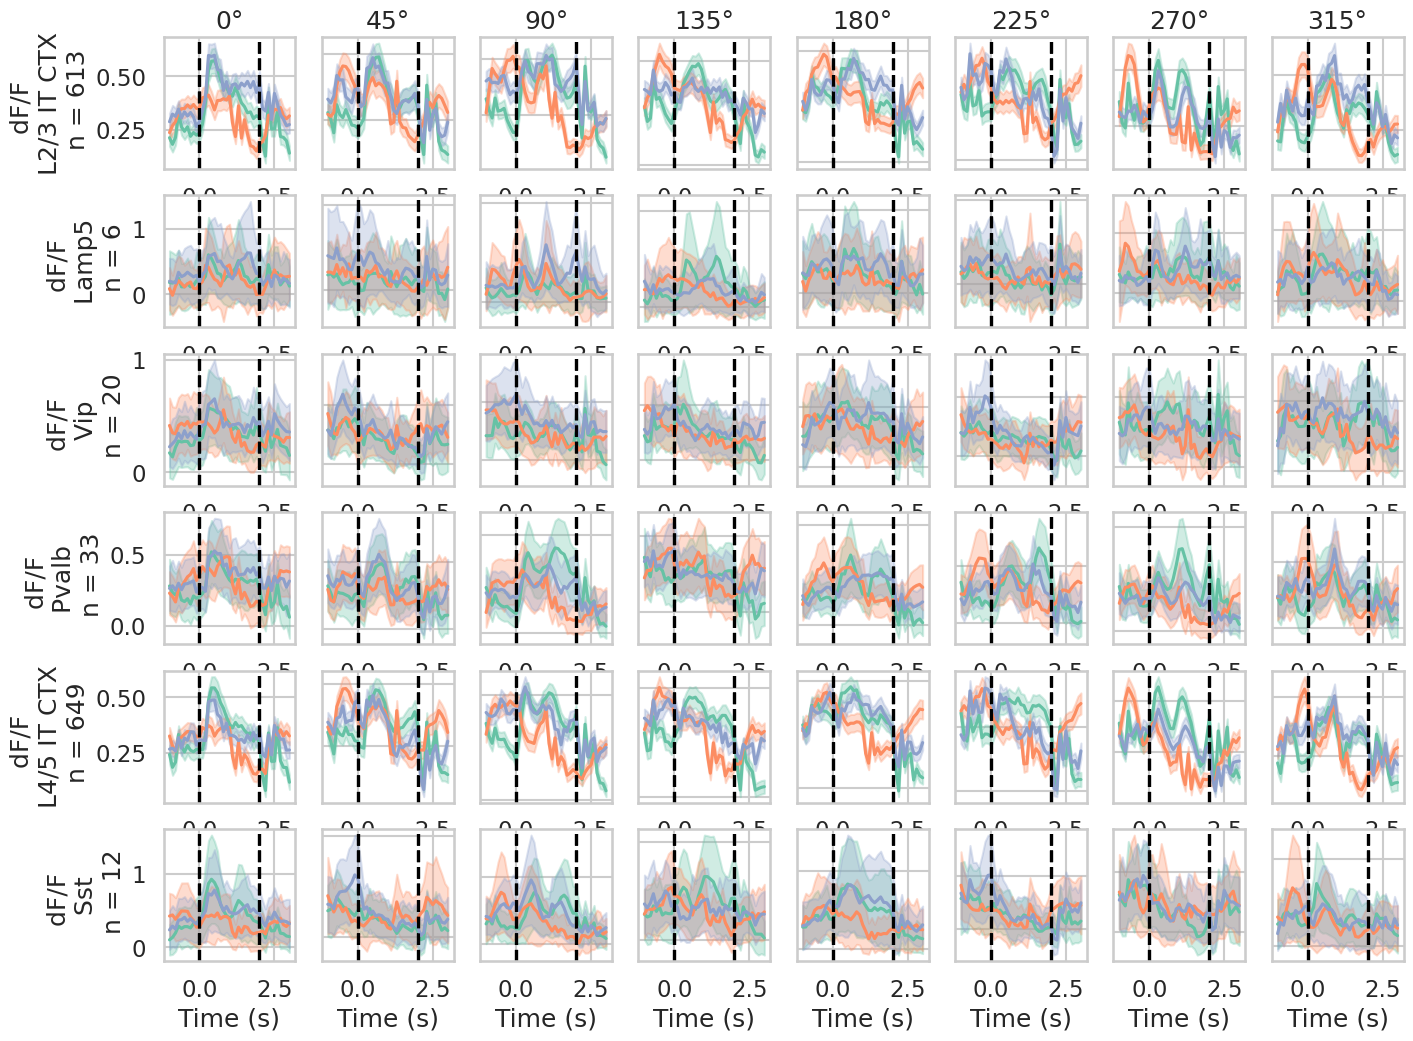

In [ ]:

orientations = np.array([0, 45, 90, 135, 180, 225, 270, 315])
contrasts = np.array([0.05, 0.1, 0.2, 0.4, 0.8])
tfs = np.array([1, 2, 4, 8, 15])

target_contrast = 0.8
target_tf = 1

SESSIONS = ['session_1', 'session_2', 'session_3']
day_colors = dict(zip(SESSIONS, sns.color_palette('Set2', n_colors=len(SESSIONS))))

for mid in MOUSE_IDS:
    if mid.startswith('h'):
        continue  # Skip hcr mice
    zarr_path = list(list(DATA_DIR.glob(f"multimodal_{mid}*"))[0].glob('*.zarr'))[0]
    z = zarr.open(str(zarr_path), mode='r')
    unique_ids = z['unique_id'][:]
    ct = z['transcriptomics/cell_type']
    ct_df = zarr_to_df(ct)
    ct_df['unique_id'] = unique_ids
    ct_df.set_index('unique_id', inplace=True)

    morph = z['morphology/mask_properties']
    morph_df = zarr_to_df(morph)
    morph_df['unique_id'] = unique_ids
    morph_df.set_index('unique_id', inplace=True)
    morph_ct_df = morph_df.join(ct_df)

    subclasses = ct_df['subclass_name'].unique()
    fig, axs = plt.subplots(len(subclasses), len(orientations), figsize=(len(orientations) * 2, len(subclasses) * 2))
    for sc in subclasses:
        mask_sc = morph_ct_df['subclass_name'] == sc
        
        for day in SESSIONS:
            sess = z[f'ophys/drifting_gratings/{day}']
            sadff = sess['stim_aligned_dff']
            gs = sadff['GratingStim']
            dff_all = gs['dff'][:]            # one full read — all 26K chunks, but only once
            dff = dff_all[1::2]
            dff_pre = dff_all[::2]
            dff_normalized = dff / np.std(dff, axis=(0, 1))
            time_rel = gs['time_relative'][:]
            running = gs['running']           # lazy
            trial_info = zarr_to_df(gs['trial_info']) # load trial info to get n_trials
            trial_info = trial_info[1::2].reindex() # only keep the trials corresponding to dff (not dff_pre)

            for i, ori in enumerate(orientations):
                mask_ori = trial_info['orientation'] == ori
                mask_contrast = trial_info['contrast'] == target_contrast
                mask_tf = trial_info['temporal_frequency'] == target_tf
                mask_trials = mask_ori & mask_contrast & mask_tf
                mean_response = np.nanmean(dff_normalized[mask_trials][:, :, mask_sc], axis=(0, 2))
                sd_response = np.nanstd(dff_normalized[mask_trials][:, :, mask_sc], axis=(0, 2)) / np.sqrt(mask_sc.sum())
                ax = axs[subclasses.tolist().index(sc), i]
                color = day_colors.get(day, '#333333')
                ax.plot(time_rel, mean_response, label=f'{day} — {ori}°', color=color)
                ax.fill_between(time_rel, mean_response - sd_response, mean_response + sd_response, alpha=0.3, color=color)
                if sc == subclasses[0]:
                    ax.set_title(f'{ori}°')
                if subclasses.tolist().index(sc) == len(subclasses) - 1:
                    ax.set_xlabel('Time (s)')
                if i == 0:
                    ax.set_ylabel(f'dF/F \n {" ".join(sc.split( )[1:-1])} \n n = {mask_sc.sum()}')
                else:
                    ax.set_yticklabels([])
                ax.axvline(0, color='k', linestyle='--')
                ax.axvline(2, color='k', linestyle='--')
            
    plt.suptitle(f'Mouse {mid} — Grating Responses (Contrast={target_contrast}, TF={target_tf} Hz)')
    plt.tight_layout()
    plt.show()
        

## A1: Cell-Type-Specific Tuning Properties

Load precomputed tuning properties from zarr stores (computed in `Compute_Tuning_Properties.ipynb`) and compare across transcriptomic subclasses.

In [5]:
# ══════════════════════════════════════════════════════════════════════
# A1.1  Compute trial-averaged responses per stimulus condition per cell
# ══════════════════════════════════════════════════════════════════════
ori_responses_list = []
crf_responses_list = []
tf_responses_list = []

for adata in adata_list:
    X = adata.X  # cells x trials
    var = adata.var.copy()
    # obs = adata.obs.copy()


    orientations = np.array([0, 45, 90, 135, 180, 225, 270, 315])
    contrasts = np.array([0.05, 0.1, 0.2, 0.4, 0.8])
    tfs = np.array([1, 2, 4, 8, 15])

    # ── Orientation tuning (use contrast-context blocks 0,2 where TF=1 Hz) ──
    ori_mask_blocks = var['stim_block'].isin([0.0, 2.0])
    ori_responses = np.zeros((adata.n_obs, len(orientations)))
    for i, ori in enumerate(orientations):
        mask = ori_mask_blocks & (var['orientation'] == ori)
        trial_idx = np.where(mask.values)[0]
        if len(trial_idx) > 0:
            ori_responses[:, i] = np.nanmean(X[:, trial_idx], axis=1)

    # ── Contrast response function (contrast-context blocks 0,2; collapse orientations) ──
    crf_responses = np.zeros((adata.n_obs, len(contrasts)))
    for i, c in enumerate(contrasts):
        mask = ori_mask_blocks & (var['contrast'] == c)
        trial_idx = np.where(mask.values)[0]
        if len(trial_idx) > 0:
            crf_responses[:, i] = np.nanmean(X[:, trial_idx], axis=1)

    # ── Temporal frequency tuning (speed-context blocks 1,3; contrast=0.8) ──
    tf_mask_blocks = var['stim_block'].isin([1.0, 3.0])
    tf_responses = np.zeros((adata.n_obs, len(tfs)))
    for i, tf in enumerate(tfs):
        mask = tf_mask_blocks & (var['temporal_frequency'] == tf)
        trial_idx = np.where(mask.values)[0]
        if len(trial_idx) > 0:
            tf_responses[:, i] = np.nanmean(X[:, trial_idx], axis=1)



    ori_responses_list.append(ori_responses)
    crf_responses_list.append(crf_responses)
    tf_responses_list.append(tf_responses)

ori_responses_all = np.concatenate(ori_responses_list, axis=0)
crf_responses_all = np.concatenate(crf_responses_list, axis=0)
tf_responses_all = np.concatenate(tf_responses_list, axis=0)

print(f"Orientation responses: {ori_responses_all.shape}")
print(f"CRF responses: {crf_responses_all.shape}")
print(f"TF responses: {tf_responses_all.shape}")

Orientation responses: (2824, 8)
CRF responses: (2824, 5)
TF responses: (2824, 5)


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A1.2  Load precomputed tuning metrics from zarr (all mice × all sessions)
# ══════════════════════════════════════════════════════════════════════

TUNING_COLS = ['OSI', 'DSI', 'pref_ori', 'max_response', 'mean_response',
               'bandwidth', 'C50', 'Rmax_crf', 'n_exponent', 'pref_TF',
               'TF_max_response', 'TF_lowpass_idx']

session_rows = []

for mouse_id in MOUSE_IDS:
    z = zarr.open(str(MULTIMODAL / f'{mouse_id}_multimodal_data.zarr'), mode='r')

    # Cell identity in zarr for robust alignment
    z_uids = z['unique_id'][:].astype(str)
    uid_to_pos = {u: i for i, u in enumerate(z_uids)}

    # Metadata for this mouse from concatenated obs
    obs_mouse = obs[obs['mouse_id'].astype(str) == str(mouse_id)].copy()
    obs_mouse['unique_id'] = obs_mouse['unique_id'].astype(str)

    for sess in SESSIONS:
        tp = z[f'ophys/drifting_gratings/{sess}/tuning_properties']

        # Build per-session tuning dataframe from zarr
        tp_cols = [c for c in TUNING_COLS if c in tp.keys()]
        tp_df = pd.DataFrame({col: tp[col][:] for col in tp_cols})

        # Add unique_id and align metadata
        n_tp = len(tp_df)
        if len(z_uids) >= n_tp:
            tp_df['unique_id'] = z_uids[:n_tp]
        else:
            tp_df['unique_id'] = np.array([f'{mouse_id}_cell_{i}' for i in range(n_tp)], dtype=object)

        meta_cols = ['mouse_id', 'subclass_name', 'supertype_name', 'cluster_name']
        obs_meta = obs_mouse[['unique_id'] + [c for c in meta_cols if c in obs_mouse.columns]].drop_duplicates('unique_id')
        tp_df = tp_df.merge(obs_meta, on='unique_id', how='left')

        # Fallback metadata assignment when direct unique_id merge is incomplete
        missing_meta = tp_df['subclass_name'].isna() if 'subclass_name' in tp_df.columns else np.zeros(len(tp_df), dtype=bool)
        if np.any(missing_meta):
            fallback = obs_mouse.reset_index(drop=True)
            n_fill = min(len(fallback), len(tp_df))
            for c in ['subclass_name', 'supertype_name', 'cluster_name']:
                if c in fallback.columns:
                    na_mask = tp_df[c].isna() if c in tp_df.columns else np.ones(len(tp_df), dtype=bool)
                    if c not in tp_df.columns:
                        tp_df[c] = np.nan
                    tp_df.loc[:n_fill-1, c] = tp_df.loc[:n_fill-1, c].where(~na_mask[:n_fill], fallback.loc[:n_fill-1, c].values)

        tp_df['mouse_id'] = str(mouse_id)
        tp_df['session'] = sess
        session_rows.append(tp_df)

tuning_df_sessions = pd.concat(session_rows, ignore_index=True)

tuning_df_sessions = tuning_df_sessions.rename(columns={
    'subclass_name': 'subclass',
    'supertype_name': 'supertype',
    'cluster_name': 'cluster'
})

# Keep a session-averaged table for downstream cells that expect one row per cell
avg_cols = [c for c in TUNING_COLS if c in tuning_df_sessions.columns]
meta_keep = ['unique_id', 'mouse_id', 'subclass', 'supertype', 'cluster']

tuning_df = (
    tuning_df_sessions
    .groupby(meta_keep, as_index=False)[avg_cols]
    .mean()
)

print(f"Loaded per-session tuning properties: {tuning_df_sessions.shape[0]} rows")
print(f"Unique mice: {tuning_df_sessions['mouse_id'].nunique()}, sessions: {tuning_df_sessions['session'].nunique()}")
print(f"Session-averaged tuning_df: {tuning_df.shape[0]} cells")
display(tuning_df_sessions.head())

Loaded per-session tuning properties: 8472 rows
Unique mice: 3, sessions: 3
Session-averaged tuning_df: 2824 cells


,OSI,DSI,pref_ori,max_response,mean_response,bandwidth,C50,Rmax_crf,n_exponent,pref_TF,TF_max_response,TF_lowpass_idx,unique_id,mouse_id,subclass,supertype,cluster,session
0,0.269148,0.033933,8.942008,0.038483,0.023634,22.016744,0.010040,6.943397e-15,0.100000,1.0,0.024456,0.755178,786297_2_142,786297,007 L2/3 IT CTX Glut,0032 L2/3 IT CTX Glut_4,0118 L2/3 IT CTX Glut_4,session_1
1,0.430981,0.082004,36.705104,0.267804,0.097240,20.697503,0.108819,5.770784e-02,10.000000,4.0,0.094266,-0.397951,786297_2_163,786297,049 Lamp5 Gaba,0200 Lamp5 Gaba_2,0718 Lamp5 Gaba_2,session_1
2,0.196324,0.428255,160.312813,0.132517,0.043378,21.230286,0.260982,3.070245e-02,3.292018,2.0,0.069433,-0.473326,786297_3_124,786297,007 L2/3 IT CTX Glut,0030 L2/3 IT CTX Glut_2,0109 L2/3 IT CTX Glut_2,session_1
3,0.223078,0.497552,171.478923,0.164531,0.060684,52.141079,1.000000,3.189469e-01,1.902606,1.0,0.118420,1.061027,786297_3_181,786297,007 L2/3 IT CTX Glut,0032 L2/3 IT CTX Glut_4,0118 L2/3 IT CTX Glut_4,session_1
4,0.552105,0.485539,73.509776,0.119163,0.039764,90.000000,0.622948,1.260475e-01,3.242056,1.0,0.075120,0.795471,786297_4_196,786297,007 L2/3 IT CTX Glut,0031 L2/3 IT CTX Glut_3,0113 L2/3 IT CTX Glut_3,session_1


Preferred-orientation change across sessions (degrees):


,subclass_short,d_s1_s2_mean,d_s2_s3_mean,d_s1_s3_mean,d_mean_mean,d_mean_median,d_mean_count
1,L2/3 IT,27.363759,30.752542,34.616757,30.911019,13.920205,1168
0,L4/5 IT,27.507197,29.714956,34.182026,30.468059,13.617456,1360
2,L5 ET,18.053946,22.307563,16.635144,18.998884,12.016727,23
5,Pvalb,35.068245,35.354743,32.716205,34.379731,15.716963,120
6,Sst,24.932176,22.242470,30.929361,26.034669,13.335862,56
3,Vip,26.797382,33.542948,35.879074,32.073135,14.260177,75
4,Lamp5,12.269599,25.646560,27.386663,21.767607,7.984455,22



Fraction of stable cells (mean pairwise change <= 22.5°):


,subclass_short,stable_fraction
0,L4/5 IT,0.644118
1,L2/3 IT,0.629281
2,L5 ET,0.739130
3,Vip,0.600000
4,Lamp5,0.681818
5,Pvalb,0.600000
6,Sst,0.678571



Kruskal-Wallis on mean pref_ori change across subclasses: H=5.82, p=4.43e-01


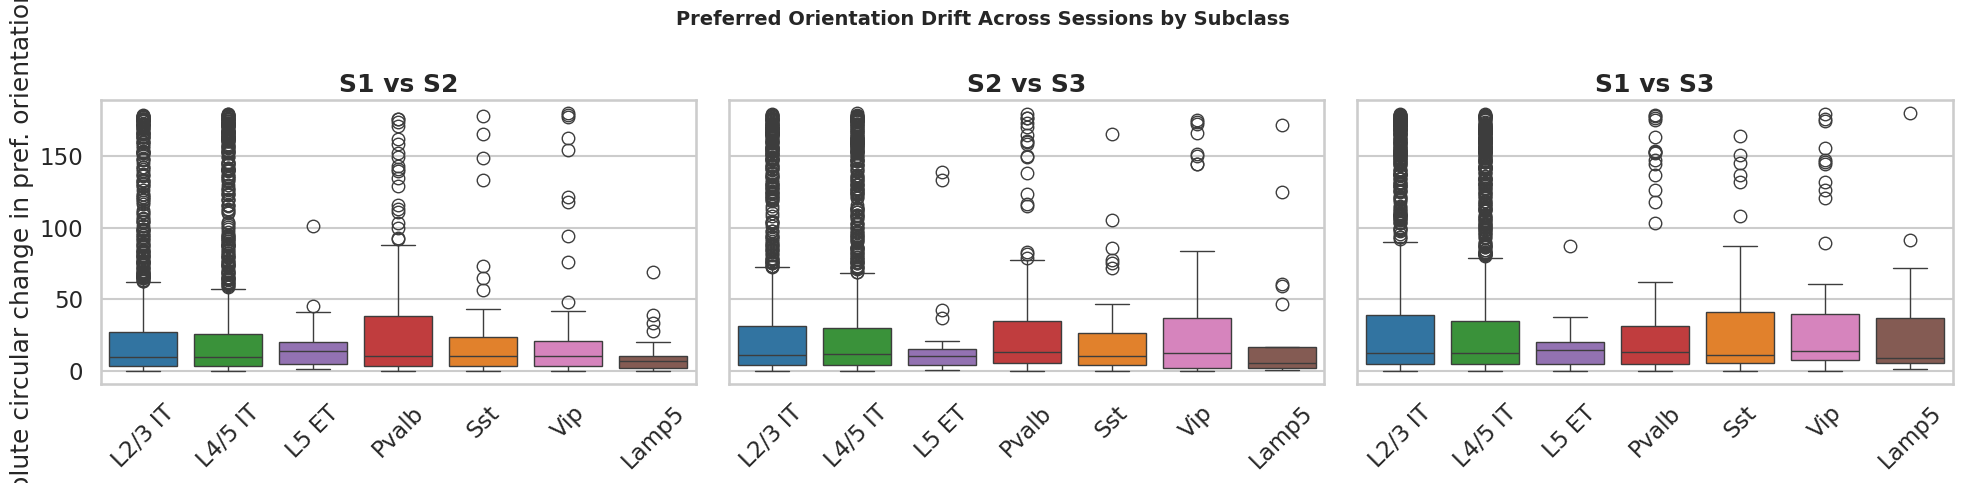

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A1.x  Preferred orientation stability across sessions (by subclass)
# ══════════════════════════════════════════════════════════════════════

def circular_abs_diff_deg(a, b, period=360.0):
    d = np.abs(a - b) % period
    return np.minimum(d, period - d)

pref_session_rows = []
for mouse_id in MOUSE_IDS:
    z = zarr.open(str(MULTIMODAL / f'{mouse_id}_multimodal_data.zarr'), mode='r')
    mouse_obs = obs[obs['mouse_id'] == mouse_id].reset_index(drop=True).copy()

    sess_pref = {}
    for sess in SESSIONS:
        tp = z[f'ophys/drifting_gratings/{sess}/tuning_properties']
        sess_pref[sess] = tp['pref_ori'][:]

    n_cells_mouse = len(mouse_obs)
    valid_lengths = all(len(sess_pref[s]) == n_cells_mouse for s in SESSIONS)
    if not valid_lengths:
        warnings.warn(f"Skipping mouse {mouse_id}: session cell counts do not match obs")
        continue

    df_mouse = pd.DataFrame({
        'mouse_id': mouse_id,
        'cell_idx_mouse': np.arange(n_cells_mouse),
        'pref_ori_s1': sess_pref['session_1'],
        'pref_ori_s2': sess_pref['session_2'],
        'pref_ori_s3': sess_pref['session_3'],
        'subclass': mouse_obs['subclass_name'].values,
        'unique_id': mouse_obs['unique_id'].values
    })
    pref_session_rows.append(df_mouse)

pref_session_df = pd.concat(pref_session_rows, ignore_index=True)

# Pairwise circular changes (degrees)
pref_session_df['d_s1_s2'] = circular_abs_diff_deg(pref_session_df['pref_ori_s1'].values, pref_session_df['pref_ori_s2'].values)
pref_session_df['d_s2_s3'] = circular_abs_diff_deg(pref_session_df['pref_ori_s2'].values, pref_session_df['pref_ori_s3'].values)
pref_session_df['d_s1_s3'] = circular_abs_diff_deg(pref_session_df['pref_ori_s1'].values, pref_session_df['pref_ori_s3'].values)
pref_session_df['d_mean'] = pref_session_df[['d_s1_s2', 'd_s2_s3', 'd_s1_s3']].mean(axis=1)

# Subclass summaries
present_subclasses_pref = [s for s in SUBCLASS_ORDER if s in pref_session_df['subclass'].unique()]
summary_pref = (
    pref_session_df[pref_session_df['subclass'].isin(present_subclasses_pref)]
    .groupby('subclass')[['d_s1_s2', 'd_s2_s3', 'd_s1_s3', 'd_mean']]
    .agg(['mean', 'median', 'std', 'count'])
)
summary_pref.columns = ['_'.join(c) for c in summary_pref.columns.to_flat_index()]
summary_pref = summary_pref.reset_index()
summary_pref['subclass_short'] = summary_pref['subclass'].map(SUBCLASS_SHORT)
summary_pref = summary_pref.sort_values('subclass', key=lambda x: x.map({k: i for i, k in enumerate(SUBCLASS_ORDER)}))

print("Preferred-orientation change across sessions (degrees):")
display(summary_pref[['subclass_short', 'd_s1_s2_mean', 'd_s2_s3_mean', 'd_s1_s3_mean', 'd_mean_mean', 'd_mean_median', 'd_mean_count']])

# Stability fraction (<= 22.5° mean pairwise change)
stable_thresh = 22.5
stable_frac = (
    pref_session_df[pref_session_df['subclass'].isin(present_subclasses_pref)]
    .assign(stable=lambda d: d['d_mean'] <= stable_thresh)
    .groupby('subclass')['stable']
    .mean()
    .rename('stable_fraction')
    .reset_index()
    .assign(subclass_short=lambda d: d['subclass'].map(SUBCLASS_SHORT))
)
print(f"\nFraction of stable cells (mean pairwise change <= {stable_thresh}°):")
display(stable_frac[['subclass_short', 'stable_fraction']])

# Kruskal-Wallis across subclasses
groups = [
    pref_session_df.loc[pref_session_df['subclass'] == s, 'd_mean'].dropna().values
    for s in present_subclasses_pref
]
groups = [g for g in groups if len(g) >= 3]
if len(groups) >= 2:
    stat, p = kruskal(*groups)
    print(f"\nKruskal-Wallis on mean pref_ori change across subclasses: H={stat:.2f}, p={p:.2e}")

# Plot
plot_df = pref_session_df[pref_session_df['subclass'].isin(present_subclasses_pref)].copy()
plot_df['subclass_short'] = plot_df['subclass'].map(SUBCLASS_SHORT)
short_order = [SUBCLASS_SHORT[s] for s in present_subclasses_pref]
short_colors = {SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for ax, met, title in zip(
    axes,
    ['d_s1_s2', 'd_s2_s3', 'd_s1_s3'],
    ['S1 vs S2', 'S2 vs S3', 'S1 vs S3']
 ):
    sns.boxplot(
        data=plot_df, x='subclass_short', y=met, order=short_order,
        palette=short_colors, ax=ax
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Absolute circular change in pref. orientation (°)')
plt.suptitle('Preferred Orientation Drift Across Sessions by Subclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Threshold: mean pairwise direction change ≤ 22.5°

  L5 ET     :   73.9%   (17/23 cells)
  Lamp5     :   68.2%   (14/22 cells)
  Sst       :   67.9%   (38/56 cells)
  L4/5 IT   :   64.4%   (876/1360 cells)
  L2/3 IT   :   62.9%   (735/1168 cells)
  Vip       :   60.0%   (45/75 cells)
  Pvalb     :   60.0%   (72/120 cells)


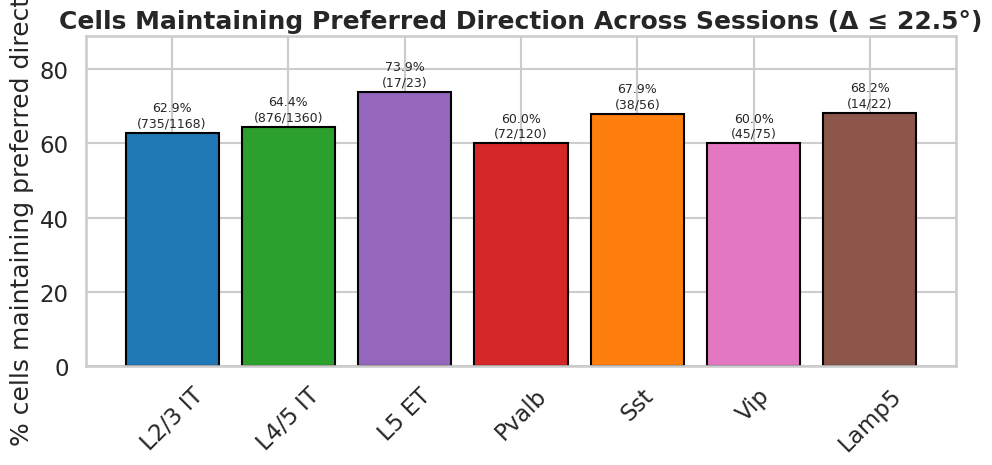

In [11]:
# Percentage of cells that maintained preferred direction per subclass
# "Maintained" = mean pairwise circular change across 3 sessions <= 22.5°

pct_stable = stable_frac.copy()
pct_stable['pct_stable'] = (pct_stable['stable_fraction'] * 100).round(1)

# Add cell counts
counts = (
    pref_session_df[pref_session_df['subclass'].isin(present_subclasses_pref)]
    .groupby('subclass').size().rename('n_cells').reset_index()
)
pct_stable = pct_stable.merge(counts, on='subclass')
pct_stable['n_stable'] = (pct_stable['stable_fraction'] * pct_stable['n_cells']).astype(int)

print(f"Threshold: mean pairwise direction change ≤ {stable_thresh}°\n")
for _, row in pct_stable.sort_values('pct_stable', ascending=False).iterrows():
    print(f"  {row['subclass_short']:10s}:  {row['pct_stable']:5.1f}%   ({row['n_stable']}/{row['n_cells']} cells)")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
order_idx = [SUBCLASS_SHORT[s] for s in present_subclasses_pref]
bar_data = pct_stable.set_index('subclass_short').loc[order_idx]
bars = ax.bar(bar_data.index, bar_data['pct_stable'],
              color=[SUBCLASS_COLORS[s] for s in present_subclasses_pref],
              edgecolor='black')
for bar, (_, row) in zip(bars, bar_data.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{row['pct_stable']:.1f}%\n({int(row['n_stable'])}/{int(row['n_cells'])})",
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% cells maintaining preferred direction')
ax.set_title(f'Cells Maintaining Preferred Direction Across Sessions (Δ ≤ {stable_thresh}°)',
             fontweight='bold')
ax.set_ylim(0, max(bar_data['pct_stable']) + 15)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Stability criterion: all pairwise pref. ori changes ≤ 22.5°



,N cells,N stable,% stable
Subclass,,,
L2/3 IT,1168.0,612.0,52.397260
L4/5 IT,1360.0,720.0,52.941176
L5 ET,23.0,16.0,69.565217
Pvalb,120.0,55.0,45.833333
Sst,56.0,30.0,53.571429
Vip,75.0,39.0,52.000000
Lamp5,22.0,15.0,68.181818


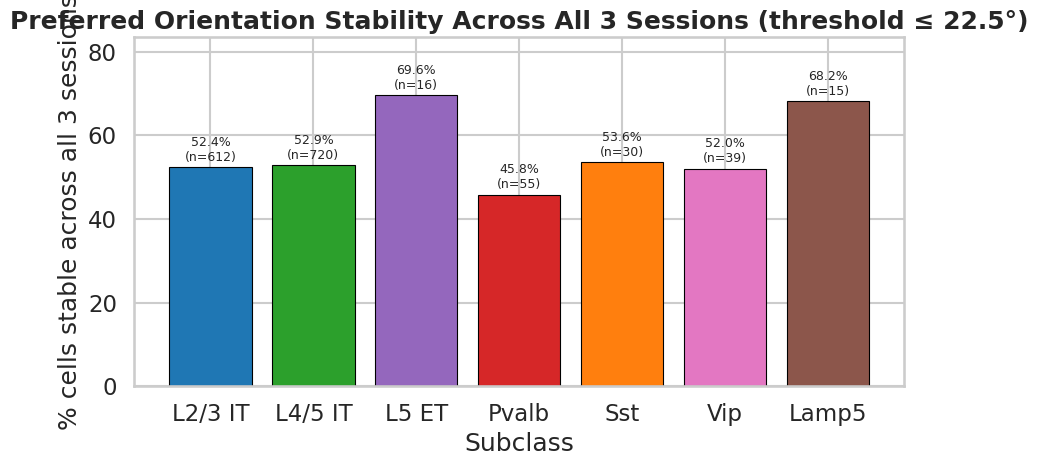

In [12]:

# ══════════════════════════════════════════════════════════════════════
# A1.x  Percentage of cells that maintained preferred orientation
#        across ALL 3 sessions (stable in every pairwise comparison)
# ══════════════════════════════════════════════════════════════════════

stable_thresh = 22.5  # degrees

all_stable = (
    (pref_session_df['d_s1_s2'] <= stable_thresh) &
    (pref_session_df['d_s2_s3'] <= stable_thresh) &
    (pref_session_df['d_s1_s3'] <= stable_thresh)
)

pref_session_df['stable_all3'] = all_stable

stable_all3 = (
    pref_session_df[pref_session_df['subclass'].isin(present_subclasses_pref)]
    .groupby('subclass')
    .apply(lambda d: pd.Series({
        'n_total': len(d),
        'n_stable': d['stable_all3'].sum(),
        'pct_stable': 100 * d['stable_all3'].mean(),
    }))
    .reset_index()
    .assign(subclass_short=lambda d: d['subclass'].map(SUBCLASS_SHORT))
    .sort_values('subclass', key=lambda x: x.map({k: i for i, k in enumerate(SUBCLASS_ORDER)}))
)

print(f"Stability criterion: all pairwise pref. ori changes ≤ {stable_thresh}°\n")
display(stable_all3[['subclass_short', 'n_total', 'n_stable', 'pct_stable']].rename(
    columns={'subclass_short': 'Subclass', 'n_total': 'N cells',
             'n_stable': 'N stable', 'pct_stable': '% stable'}
).set_index('Subclass'))

# ── Bar chart ──
fig, ax = plt.subplots(figsize=(9, 5))
short_order_s = [SUBCLASS_SHORT[s] for s in present_subclasses_pref]
short_pal_s = {SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}
bars = ax.bar(
    stable_all3['subclass_short'],
    stable_all3['pct_stable'],
    color=[short_pal_s.get(s, '#888') for s in stable_all3['subclass_short']],
    edgecolor='black', linewidth=0.8
)
for bar, (_, row) in zip(bars, stable_all3.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{row['pct_stable']:.1f}%\n(n={int(row['n_stable'])})",
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% cells stable across all 3 sessions')
ax.set_xlabel('Subclass')
ax.set_title(f'Preferred Orientation Stability Across All 3 Sessions (threshold ≤ {stable_thresh}°)',
             fontweight='bold')
ax.set_ylim(0, max(stable_all3['pct_stable']) * 1.2)
plt.tight_layout()
plt.show()


In [3]:
# ══════════════════════════════════════════════════════════════════════
# A1.custom  Load tuning properties from zarr (all mice) and test
#            differences across:
#            (1) subclasses
#            (2) supertypes within each subclass
#            (3) clusters within each subclass
# ══════════════════════════════════════════════════════════════════════

TUNING_COLS = [
    'OSI', 'DSI', 'pref_ori', 'max_response', 'mean_response',
    'bandwidth', 'C50', 'Rmax_crf', 'n_exponent', 'pref_TF',
    'TF_max_response', 'TF_lowpass_idx'
]

rows = []

for mid in MOUSE_IDS:
    mouse_dirs = sorted(DATA_DIR.glob(f'multimodal_{mid}*'))
    if len(mouse_dirs) == 0:
        warnings.warn(f'No folder found for mouse {mid}')
        continue

    mouse_dir = mouse_dirs[0]
    zarr_files = list(mouse_dir.glob('*.zarr'))
    h5ad_files = list(mouse_dir.glob('*.h5ad'))
    if len(zarr_files) == 0 or len(h5ad_files) == 0:
        warnings.warn(f'Missing zarr or h5ad for mouse {mid}')
        continue

    z = zarr.open(str(zarr_files[0]), mode='r')
    adata_mouse = ad.read_h5ad(h5ad_files[0])

    obs_meta = adata_mouse.obs.copy()
    obs_meta['unique_id'] = obs_meta['unique_id'].astype(str)
    keep_cols = ['unique_id', 'subclass_name', 'supertype_name', 'cluster_name', 'mouse_id']
    keep_cols = [c for c in keep_cols if c in obs_meta.columns]
    obs_meta = obs_meta[keep_cols].drop_duplicates('unique_id')

    z_uids = z['unique_id'][:].astype(str)

    for sess in SESSIONS:
        tp_path = f'ophys/drifting_gratings/{sess}/tuning_properties'
        if tp_path not in z:
            continue

        tp = z[tp_path]
        present_cols = [c for c in TUNING_COLS if c in tp.keys()]
        if len(present_cols) == 0:
            continue

        tp_df = pd.DataFrame({c: tp[c][:] for c in present_cols})
        n_tp = len(tp_df)
        tp_df['unique_id'] = z_uids[:n_tp]
        tp_df['session'] = sess
        tp_df['mouse_id'] = str(mid)

        tp_df = tp_df.merge(obs_meta, on='unique_id', how='left', suffixes=('', '_meta'))

        for col in ['mouse_id', 'subclass_name', 'supertype_name', 'cluster_name']:
            meta_col = f'{col}_meta'
            if meta_col in tp_df.columns:
                if col in tp_df.columns:
                    tp_df[col] = tp_df[col].where(tp_df[col].notna(), tp_df[meta_col])
                    tp_df = tp_df.drop(columns=[meta_col])
                else:
                    tp_df = tp_df.rename(columns={meta_col: col})

        rows.append(tp_df)

if len(rows) == 0:
    raise RuntimeError('No tuning properties were loaded from zarr files.')

tuning_df_sessions = pd.concat(rows, ignore_index=True)
tuning_df_sessions = tuning_df_sessions.rename(columns={
    'subclass_name': 'subclass',
    'supertype_name': 'supertype',
    'cluster_name': 'cluster'
})

print(f'Loaded rows: {len(tuning_df_sessions):,}')
print(f'Mice: {tuning_df_sessions["mouse_id"].nunique()}, Sessions: {tuning_df_sessions["session"].nunique()}')

metrics = [m for m in ['OSI', 'DSI', 'C50', 'Rmax_crf', 'pref_TF', 'TF_lowpass_idx', 'bandwidth', 'max_response'] if m in tuning_df_sessions.columns]

# 1) Differences across subclasses
print('\n=== Differences across subclasses (Kruskal-Wallis) ===')
subclass_stats = []
for met in metrics:
    tmp = tuning_df_sessions[['subclass', met]].dropna()
    counts = tmp['subclass'].value_counts()
    keep_subclasses = counts[counts >= 10].index
    tmp = tmp[tmp['subclass'].isin(keep_subclasses)]

    if tmp['subclass'].nunique() < 2:
        continue

    groups = [g[met].values for _, g in tmp.groupby('subclass') if len(g) >= 10]
    if len(groups) < 2:
        continue

    stat, p = kruskal(*groups)
    subclass_stats.append({'metric': met, 'H': stat, 'p': p, 'n_subclasses': len(groups)})

subclass_stats_df = pd.DataFrame(subclass_stats).sort_values('p') if len(subclass_stats) else pd.DataFrame()
display(subclass_stats_df)


def nested_kruskal(df, child_col, min_cells_per_group=10):
    out = []
    for sc, d_sc in df.groupby('subclass'):
        for met in metrics:
            d0 = d_sc[[child_col, met]].dropna()
            if d0.empty:
                continue

            vc = d0[child_col].value_counts()
            keep = vc[vc >= min_cells_per_group].index
            d0 = d0[d0[child_col].isin(keep)]

            if d0[child_col].nunique() < 2:
                continue

            groups = [g[met].values for _, g in d0.groupby(child_col)]
            groups = [g for g in groups if len(g) >= min_cells_per_group]
            if len(groups) < 2:
                continue

            stat, p = kruskal(*groups)
            out.append({
                'subclass': sc,
                'metric': met,
                'H': stat,
                'p': p,
                'n_groups': len(groups)
            })
    return pd.DataFrame(out)

# 2) Differences across supertypes within each subclass
print('\n=== Differences across supertypes within subclass (Kruskal-Wallis) ===')
supertype_nested = nested_kruskal(tuning_df_sessions, child_col='supertype', min_cells_per_group=10)
if len(supertype_nested):
    display(supertype_nested.sort_values('p').reset_index(drop=True))
else:
    print('No valid supertype-within-subclass tests (insufficient group sizes).')

# 3) Differences across clusters within each subclass
print('\n=== Differences across clusters within subclass (Kruskal-Wallis) ===')
cluster_nested = nested_kruskal(tuning_df_sessions, child_col='cluster', min_cells_per_group=10)
if len(cluster_nested):
    display(cluster_nested.sort_values('p').reset_index(drop=True))
else:
    print('No valid cluster-within-subclass tests (insufficient group sizes).')

Loaded rows: 12,669
Mice: 9, Sessions: 3

=== Differences across subclasses (Kruskal-Wallis) ===


,metric,H,p,n_subclasses
0,OSI,2713.567551,0.000000e+00,9
1,DSI,2531.188088,0.000000e+00,9
7,max_response,1961.057595,0.000000e+00,9
3,Rmax_crf,304.844672,3.831692e-61,9
4,pref_TF,156.618955,8.140647e-30,9
5,TF_lowpass_idx,103.243582,9.263239e-19,9
6,bandwidth,65.753981,3.423133e-11,9
2,C50,8.575631,3.793487e-01,9



=== Differences across supertypes within subclass (Kruskal-Wallis) ===


,subclass,metric,H,p,n_groups
0,006 L4/5 IT CTX Glut,TF_lowpass_idx,115.102280,5.934618e-24,5
1,006 L4/5 IT CTX Glut,DSI,108.774229,1.328572e-22,5
2,006 L4/5 IT CTX Glut,OSI,76.288202,1.063883e-15,5
3,006 L4/5 IT CTX Glut,pref_TF,61.727623,1.256940e-12,5
4,046 Vip Gaba,max_response,63.785183,2.637255e-11,8
...,...,...,...,...,...
59,046 Vip Gaba,C50,3.586887,8.259387e-01,8
60,006 L4/5 IT CTX Glut,C50,1.503944,8.259426e-01,5
61,053 Sst Gaba,C50,1.251202,8.695987e-01,5
62,006 L4/5 IT CTX Glut,bandwidth,0.869606,9.288803e-01,5



=== Differences across clusters within subclass (Kruskal-Wallis) ===


,subclass,metric,H,p,n_groups
0,006 L4/5 IT CTX Glut,TF_lowpass_idx,149.328577,2.814233e-25,14
1,006 L4/5 IT CTX Glut,DSI,133.272814,4.657629e-22,14
2,006 L4/5 IT CTX Glut,OSI,112.931514,4.971159e-18,14
3,052 Pvalb Gaba,max_response,87.235614,1.690691e-15,9
4,046 Vip Gaba,max_response,105.596553,8.081327e-15,18
...,...,...,...,...,...
67,051 Pvalb chandelier Gaba,Rmax_crf,0.065654,7.977735e-01,2
68,022 L5 ET CTX Glut,DSI,0.988047,8.041443e-01,4
69,046 Vip Gaba,C50,10.977864,8.577124e-01,18
70,051 Pvalb chandelier Gaba,TF_lowpass_idx,0.008370,9.271032e-01,2


In [5]:
# ══════════════════════════════════════════════════════════════════════
# A1.5  Extract pre-computed GLM coefficients from zarr and add to tuning_df
# ══════════════════════════════════════════════════════════════════════

# --- Preconditions ---
required_globals = ['obs', 'tuning_df', 'MOUSE_IDS', 'SESSIONS', 'MULTIMODAL']
missing_globals = [g for g in required_globals if g not in globals()]
if len(missing_globals) > 0:
    raise NameError(f"Missing required variables: {missing_globals}. Run the data-loading cells first.")

if 'mouse_id' not in tuning_df.columns:
    raise KeyError("tuning_df must contain 'mouse_id'. Ensure A1.2 has been run and tuning_df was not overwritten.")
if 'unique_id' not in tuning_df.columns:
    raise KeyError("tuning_df must contain 'unique_id' for robust cell alignment.")

all_glm_coef_cols = set()

for mouse_id in MOUSE_IDS:
    z = zarr.open(str(MULTIMODAL / f'{mouse_id}_multimodal_data.zarr'), mode='r')

    # Use persistent tuning_df indexing (do NOT overwrite tuning_df)
    mouse_mask = tuning_df['mouse_id'].astype(str).values == str(mouse_id)
    mouse_rows = tuning_df.index[mouse_mask]
    n_cells_mouse = int(np.sum(mouse_mask))
    if n_cells_mouse == 0:
        warnings.warn(f"Mouse {mouse_id}: no rows in tuning_df; skipping.")
        continue

    # Build alignment from tuning_df unique_id -> zarr cell index
    z_uids = z['unique_id'][:].astype(str)
    uid_to_pos = {u: i for i, u in enumerate(z_uids)}
    mouse_uids = tuning_df.loc[mouse_rows, 'unique_id'].astype(str).values
    z_pos = np.array([uid_to_pos.get(u, -1) for u in mouse_uids])
    valid_uid = z_pos >= 0

    if not np.any(valid_uid):
        warnings.warn(f"Mouse {mouse_id}: no unique_id overlap between tuning_df and zarr; using positional fallback.")

    # Average GLM coefficients across sessions
    session_glm_list = []
    glm_coef_cols_mouse = None
    for sess in SESSIONS:
        glm_group = z[f'ophys/drifting_gratings/{sess}/glm/coef']
        coef_cols = [k for k in glm_group.keys() if k.startswith('glm-coef_contrast_') and k.endswith('_direction_pref_0')]
        coef_cols += [k for k in glm_group.keys() if k.startswith('glm-coef_TF_') and k.endswith('_direction_pref_0')]

        if glm_coef_cols_mouse is None:
            glm_coef_cols_mouse = coef_cols

        session_glm_dict = {k: glm_group[k][:] for k in coef_cols}
        session_glm_list.append(session_glm_dict)

    if glm_coef_cols_mouse is None or len(glm_coef_cols_mouse) == 0:
        warnings.warn(f"Mouse {mouse_id}: no GLM coefficient columns found; skipping.")
        continue

    print(f"Mouse {mouse_id}: averaging GLM coefficients for {n_cells_mouse} cells across {len(session_glm_list)} sessions")

    for coef_name in glm_coef_cols_mouse:
        coef_stack = [s[coef_name] for s in session_glm_list if coef_name in s]
        if len(coef_stack) == 0:
            continue

        coef_avg = np.nanmean(np.array(coef_stack), axis=0)
        coef_avg = np.asarray(coef_avg)

        # Coerce to (n_cells, n_features)
        if coef_avg.ndim == 1:
            coef_mat = coef_avg[:, None]
        else:
            coef_mat = coef_avg

        # Align rows either by unique_id mapping or by positional fallback
        if np.any(valid_uid):
            coef_aligned = np.full((n_cells_mouse, coef_mat.shape[1]), np.nan)
            coef_aligned[valid_uid, :] = coef_mat[z_pos[valid_uid], :]
        else:
            if coef_mat.shape[0] < n_cells_mouse:
                warnings.warn(
                    f"Mouse {mouse_id}, Coef {coef_name}: got {coef_mat.shape[0]} cells, expected {n_cells_mouse}; skipping."
                )
                continue
            coef_aligned = coef_mat[:n_cells_mouse, :]

        if coef_aligned.shape[1] == 1:
            tuning_df.loc[mouse_rows, coef_name] = coef_aligned[:, 0]
        else:
            n_pc = min(2, coef_aligned.shape[1])
            pca_ = PCA(n_components=n_pc)
            valid_rows = ~np.isnan(coef_aligned).any(axis=1)
            if np.sum(valid_rows) < n_pc:
                warnings.warn(f"Mouse {mouse_id}, Coef {coef_name}: insufficient valid rows for PCA; skipping PCA projection.")
                continue
            coef_pc = np.full((coef_aligned.shape[0], n_pc), np.nan)
            coef_pc[valid_rows] = pca_.fit_transform(coef_aligned[valid_rows])
            for j in range(coef_pc.shape[1]):
                tuning_df.loc[mouse_rows, f"{coef_name}_pc{j}"] = coef_pc[:, j]

        all_glm_coef_cols.add(coef_name)

print(f"Extracted {len(all_glm_coef_cols)} GLM coefficient columns from zarr")
print(f"GLM columns: {sorted(list(all_glm_coef_cols))[:5]}... (showing first 5)")
print(f"tuning_df shape: {tuning_df.shape}")

NameError: Missing required variables: ['obs', 'tuning_df', 'MULTIMODAL']. Run the data-loading cells first.

In [4]:
# ══════════════════════════════════════════════════════════════════════
# A1.5b  Visualize extracted GLM coefficients by subclass (box plots)
# ══════════════════════════════════════════════════════════════════════

if 'all_glm_coef_cols' not in globals() or len(all_glm_coef_cols) == 0:
    raise NameError("No GLM coefficient set found. Run A1.5 first.")

if 'subclass' not in tuning_df.columns:
    raise KeyError("tuning_df must contain 'subclass' before plotting.")

present_subclasses_glm = [s for s in SUBCLASS_ORDER if s in tuning_df['subclass'].dropna().unique()]
short_order = [SUBCLASS_SHORT[s] for s in present_subclasses_glm]
short_colors = {SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}

# Collect plottable GLM columns (exact columns + PCA projections if present)
glm_plot_cols = []
for base in sorted(all_glm_coef_cols):
    if base in tuning_df.columns and tuning_df[base].notna().any():
        glm_plot_cols.append(base)
    pc_cols = sorted([c for c in tuning_df.columns if c.startswith(f'{base}_pc') and tuning_df[c].notna().any()])
    glm_plot_cols.extend(pc_cols)

# Keep unique order and limit for readability
glm_plot_cols = list(dict.fromkeys(glm_plot_cols))
max_plots = 12
glm_plot_cols = glm_plot_cols[:max_plots]

if len(glm_plot_cols) == 0:
    raise RuntimeError("No non-empty GLM coefficient columns found in tuning_df to plot.")

plot_df = tuning_df[tuning_df['subclass'].isin(present_subclasses_glm)].copy()
plot_df['subclass_short'] = plot_df['subclass'].map(SUBCLASS_SHORT)

n_cols = 3
n_rows = int(np.ceil(len(glm_plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows), squeeze=False)

for ax, col in zip(axes.flat, glm_plot_cols):
    d = plot_df[['subclass_short', col]].dropna()
    if d.empty:
        ax.axis('off')
        continue
    sns.boxplot(
        data=d, x='subclass_short', y=col, order=short_order,
        palette=short_colors, ax=ax, showfliers=False
    )
    ax.set_title(col.replace('glm-coef_', ''), fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

for ax in axes.flat[len(glm_plot_cols):]:
    ax.axis('off')

plt.suptitle('A1.5: GLM Coefficient Distributions by Transcriptomic Subclass', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: No GLM coefficient set found. Run A1.5 first.

=== Kruskal-Wallis H-test across subclasses ===
  OSI                 : H=    8.57, p=1.99e-01 ns
  DSI                 : H=   36.92, p=1.83e-06 ***
  C50                 : H=    0.97, p=9.87e-01 ns
  Rmax_crf            : H=   11.57, p=7.23e-02 ns
  pref_TF             : H=   12.72, p=4.77e-02 *
  TF_lowpass_idx      : H=   14.37, p=2.58e-02 *
  bandwidth           : H=   31.27, p=2.25e-05 ***
  max_response        : H=   24.75, p=3.80e-04 ***


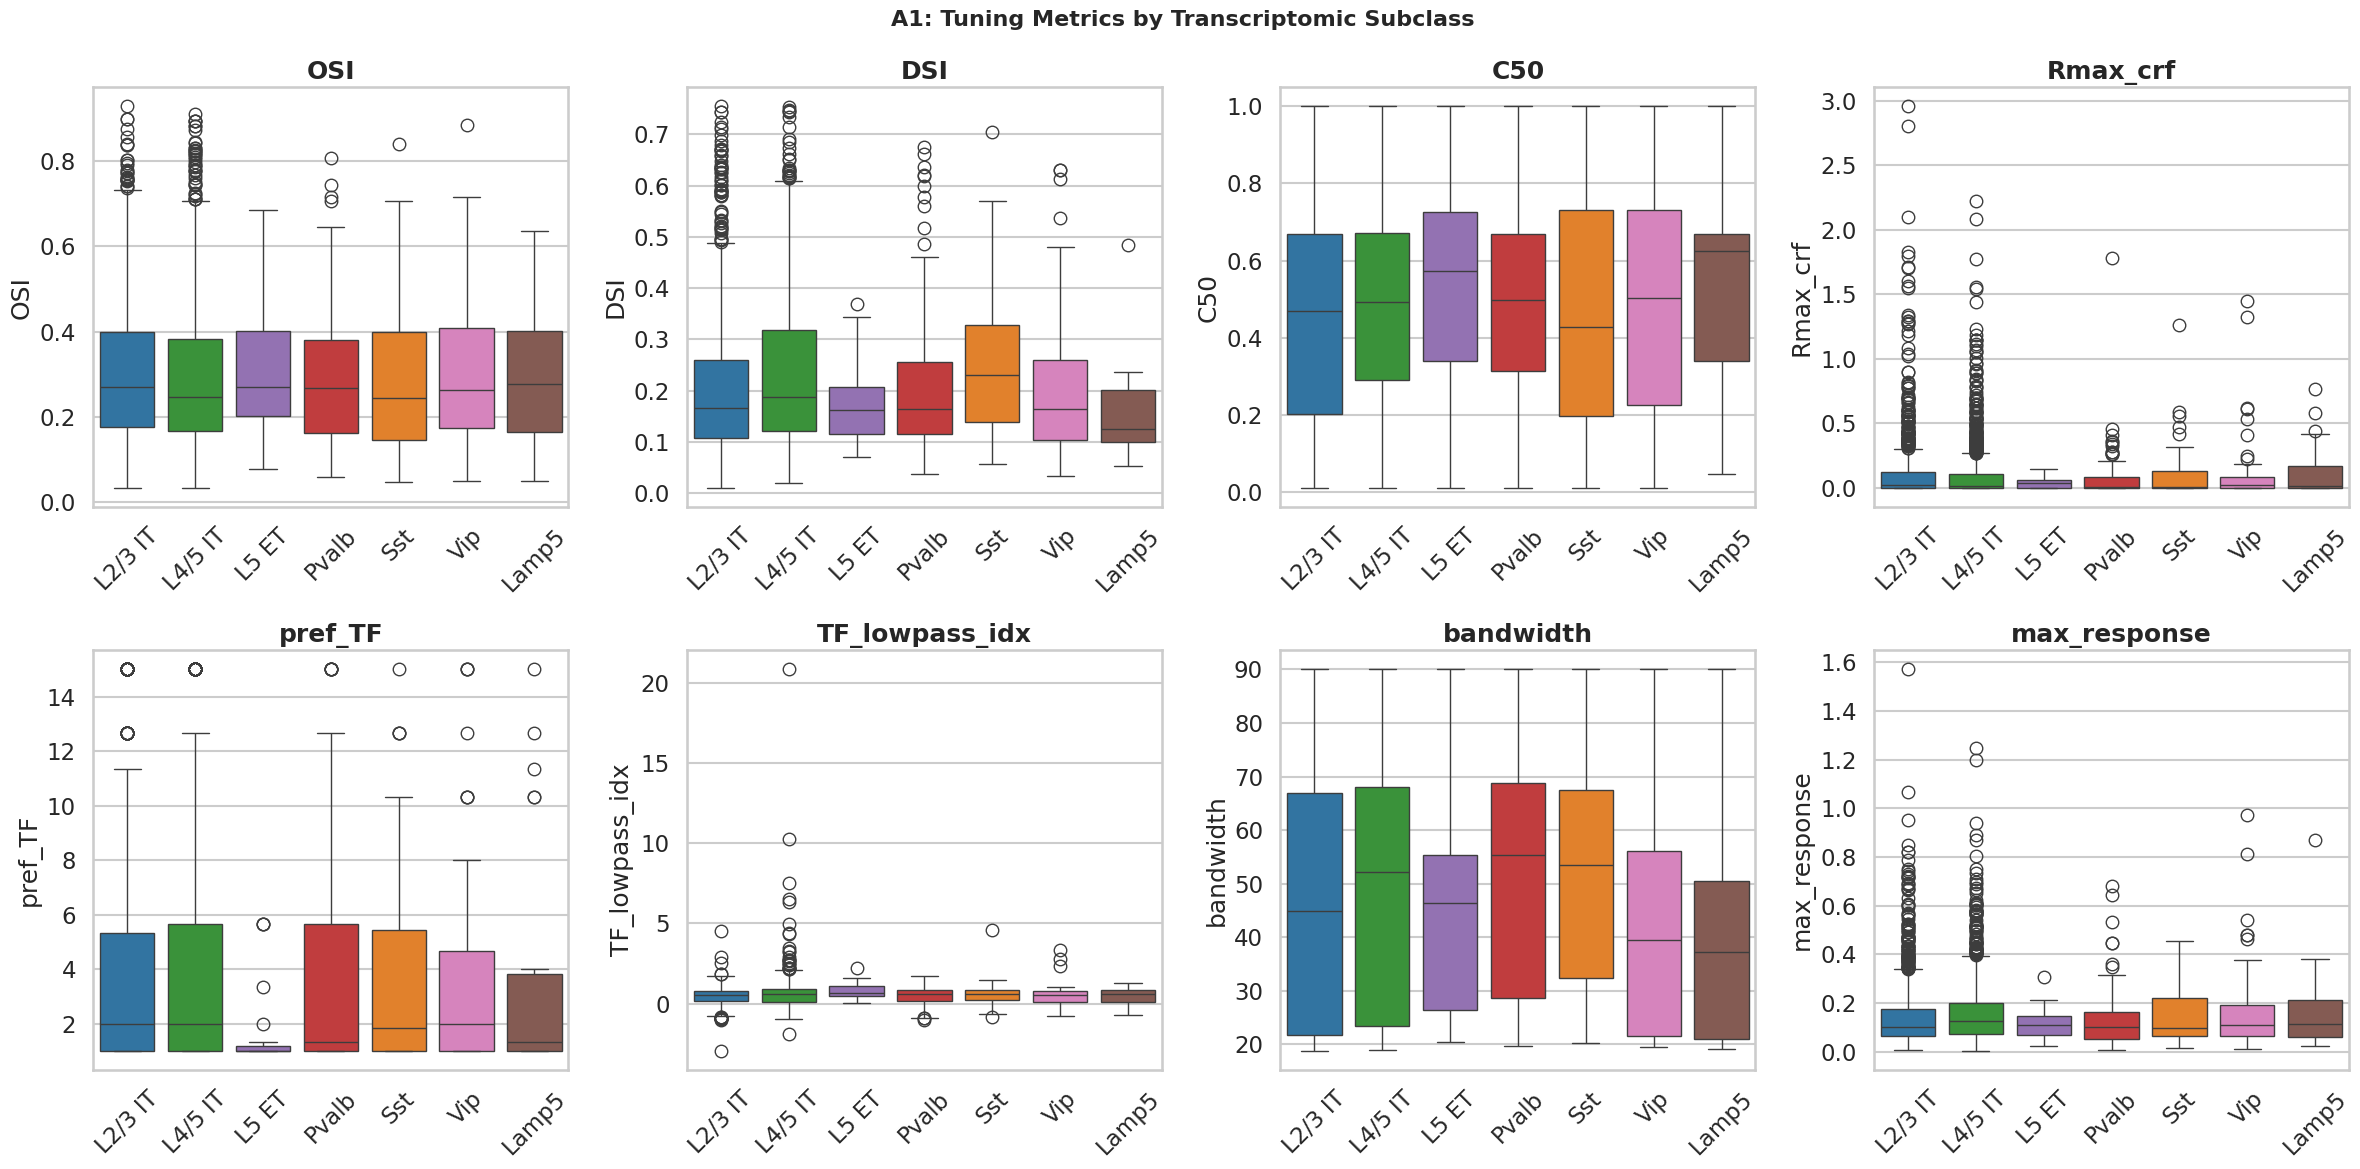

NameError: name 'ori_responses_all' is not defined

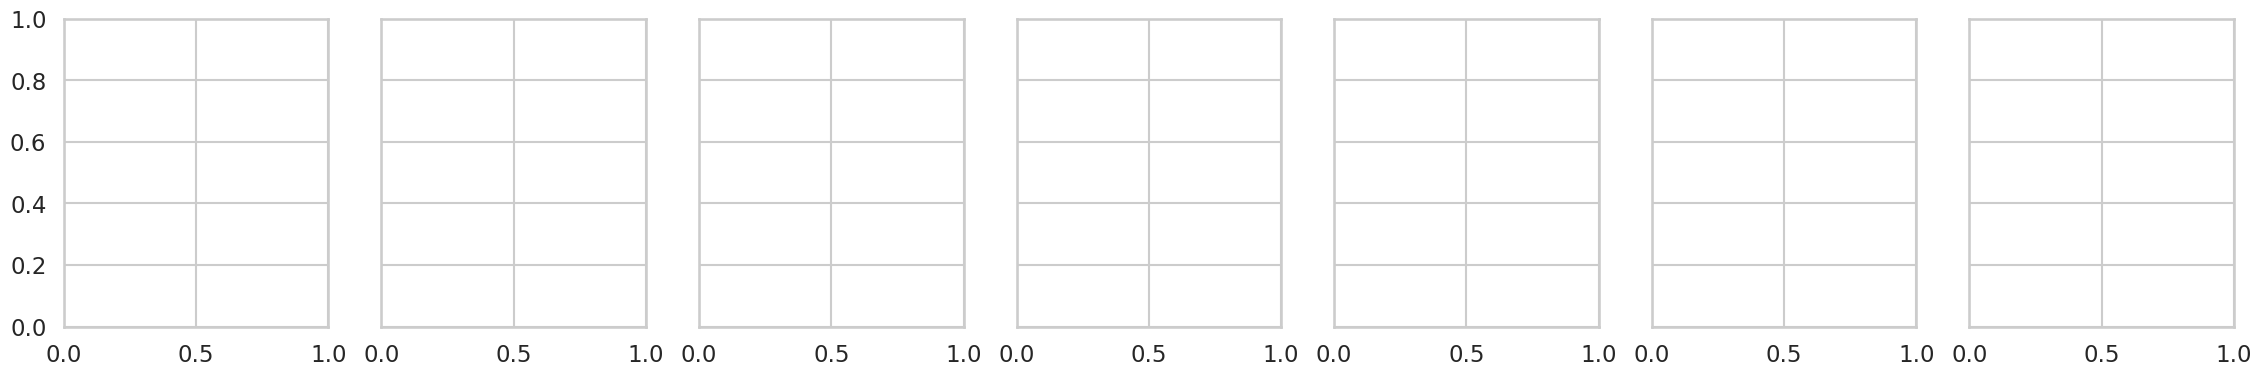

In [24]:
# ══════════════════════════════════════════════════════════════════════
# A1.3a  Compare tuning parameters across subclasses (stats + visualization)
# ══════════════════════════════════════════════════════════════════════

metrics = ['OSI', 'DSI', 'C50', 'Rmax_crf', 'pref_TF', 'TF_lowpass_idx', 'bandwidth', 'max_response']
present_subclasses = [s for s in SUBCLASS_ORDER if s in tuning_df['subclass'].unique()]

# ── Kruskal-Wallis tests ──
print("=== Kruskal-Wallis H-test across subclasses ===")
for met in metrics:
    groups = [tuning_df.loc[tuning_df['subclass'] == s, met].dropna().values for s in present_subclasses]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"  {met:20s}: H={stat:8.2f}, p={p:.2e} {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}")

# ── Visualization: Box plots of tuning metrics by subclass ──
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
for ax, met in zip(axes.flat, metrics):
    data_plot = tuning_df[tuning_df['subclass'].isin(present_subclasses)].copy()
    data_plot['subclass_short'] = data_plot['subclass'].map(SUBCLASS_SHORT)
    short_order = [SUBCLASS_SHORT[s] for s in present_subclasses]
    short_colors = {SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}
    sns.boxplot(data=data_plot, x='subclass_short', y=met, order=short_order,
                palette=short_colors, ax=ax)
    ax.set_title(met, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('A1: Tuning Metrics by Transcriptomic Subclass', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Population orientation tuning curves per subclass ──
fig, axes = plt.subplots(1, len(present_subclasses), figsize=(4*len(present_subclasses), 4), sharey=True)
for ax, sc in zip(axes, present_subclasses):
    mask = obs['subclass_name'].values == sc
    resp = ori_responses_all[mask]
    mean_r = np.nanmean(resp, axis=0)
    sem_r = np.nanstd(resp, axis=0) / np.sqrt(np.sum(mask))
    ax.errorbar(orientations, mean_r, yerr=sem_r, color=SUBCLASS_COLORS[sc],
                linewidth=2, capsize=3, marker='o')
    ax.set_title(SUBCLASS_SHORT[sc], color=SUBCLASS_COLORS[sc], fontweight='bold')
    ax.set_xlabel('Direction (°)')
    ax.set_xticks(orientations)
axes[0].set_ylabel('Mean ΔF/F')
plt.suptitle('A1: Population Orientation Tuning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Population CRF per subclass ──
fig, axes = plt.subplots(1, len(present_subclasses), figsize=(4*len(present_subclasses), 4), sharey=True)
for ax, sc in zip(axes, present_subclasses):
    mask = obs['subclass_name'].values == sc
    resp = crf_responses_all[mask]
    mean_r = np.nanmean(resp, axis=0)
    sem_r = np.nanstd(resp, axis=0) / np.sqrt(np.sum(mask))
    ax.errorbar(contrasts, mean_r, yerr=sem_r, color=SUBCLASS_COLORS[sc],
                linewidth=2, capsize=3, marker='o')
    ax.set_xscale('log')
    ax.set_title(SUBCLASS_SHORT[sc], color=SUBCLASS_COLORS[sc], fontweight='bold')
    ax.set_xlabel('Contrast')
axes[0].set_ylabel('Mean ΔF/F')
plt.suptitle('A1: Contrast Response Functions by Subclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Population TF tuning per subclass ──
fig, axes = plt.subplots(1, len(present_subclasses), figsize=(4*len(present_subclasses), 4), sharey=True)
for ax, sc in zip(axes, present_subclasses):
    mask = obs['subclass_name'].values == sc
    resp = tf_responses_all[mask]
    mean_r = np.nanmean(resp, axis=0)
    sem_r = np.nanstd(resp, axis=0) / np.sqrt(np.sum(mask))
    ax.errorbar(tfs, mean_r, yerr=sem_r, color=SUBCLASS_COLORS[sc],
                linewidth=2, capsize=3, marker='o')
    ax.set_xscale('log')
    ax.set_title(SUBCLASS_SHORT[sc], color=SUBCLASS_COLORS[sc], fontweight='bold')
    ax.set_xlabel('TF (Hz)')
axes[0].set_ylabel('Mean ΔF/F')
plt.suptitle('A1: Temporal Frequency Tuning by Subclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


=== Kruskal-Wallis: supertype within subclass ===
  Sst      | C50           : H=    0.67, p=4.13e-01, groups=2 ns
  L4/5 IT  | C50           : H=    1.08, p=7.81e-01, groups=4 ns
  L2/3 IT  | C50           : H=    0.16, p=9.23e-01, groups=3 ns
  Vip      | C50           : H=    0.00, p=9.70e-01, groups=2 ns
  L4/5 IT  | DSI           : H=   22.92, p=4.19e-05, groups=4 ***
  Sst      | DSI           : H=    1.29, p=2.56e-01, groups=2 ns
  Vip      | DSI           : H=    0.04, p=8.45e-01, groups=2 ns
  L2/3 IT  | DSI           : H=    0.16, p=9.25e-01, groups=3 ns
  L4/5 IT  | OSI           : H=   19.01, p=2.73e-04, groups=4 ***
  Vip      | OSI           : H=    1.11, p=2.93e-01, groups=2 ns
  Sst      | OSI           : H=    0.32, p=5.74e-01, groups=2 ns
  L2/3 IT  | OSI           : H=    1.09, p=5.78e-01, groups=3 ns
  L2/3 IT  | Rmax_crf      : H=    7.59, p=2.25e-02, groups=3 *
  L4/5 IT  | Rmax_crf      : H=    9.06, p=2.85e-02, groups=4 *
  Sst      | Rmax_crf      : H=    0.79,

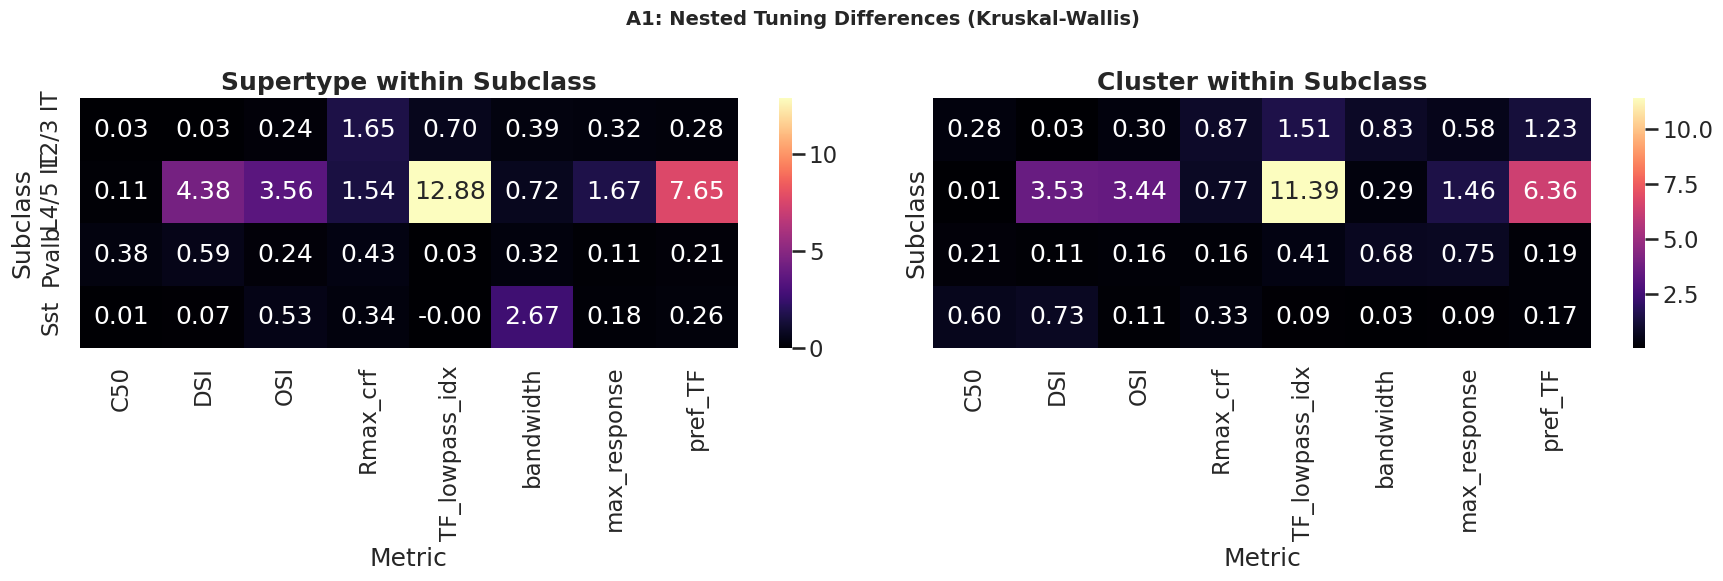

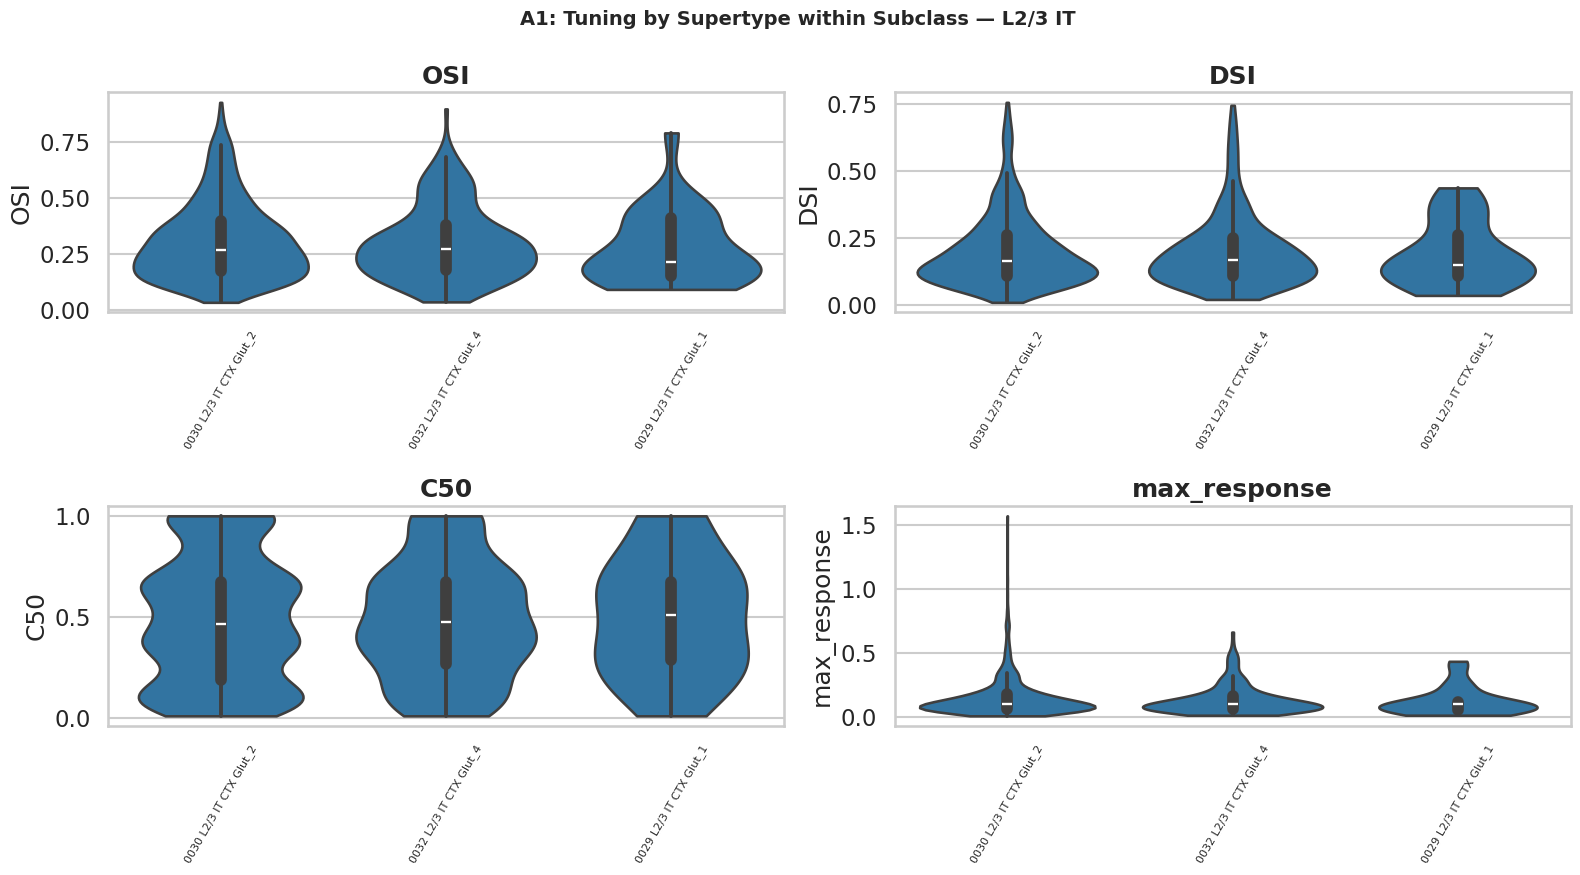

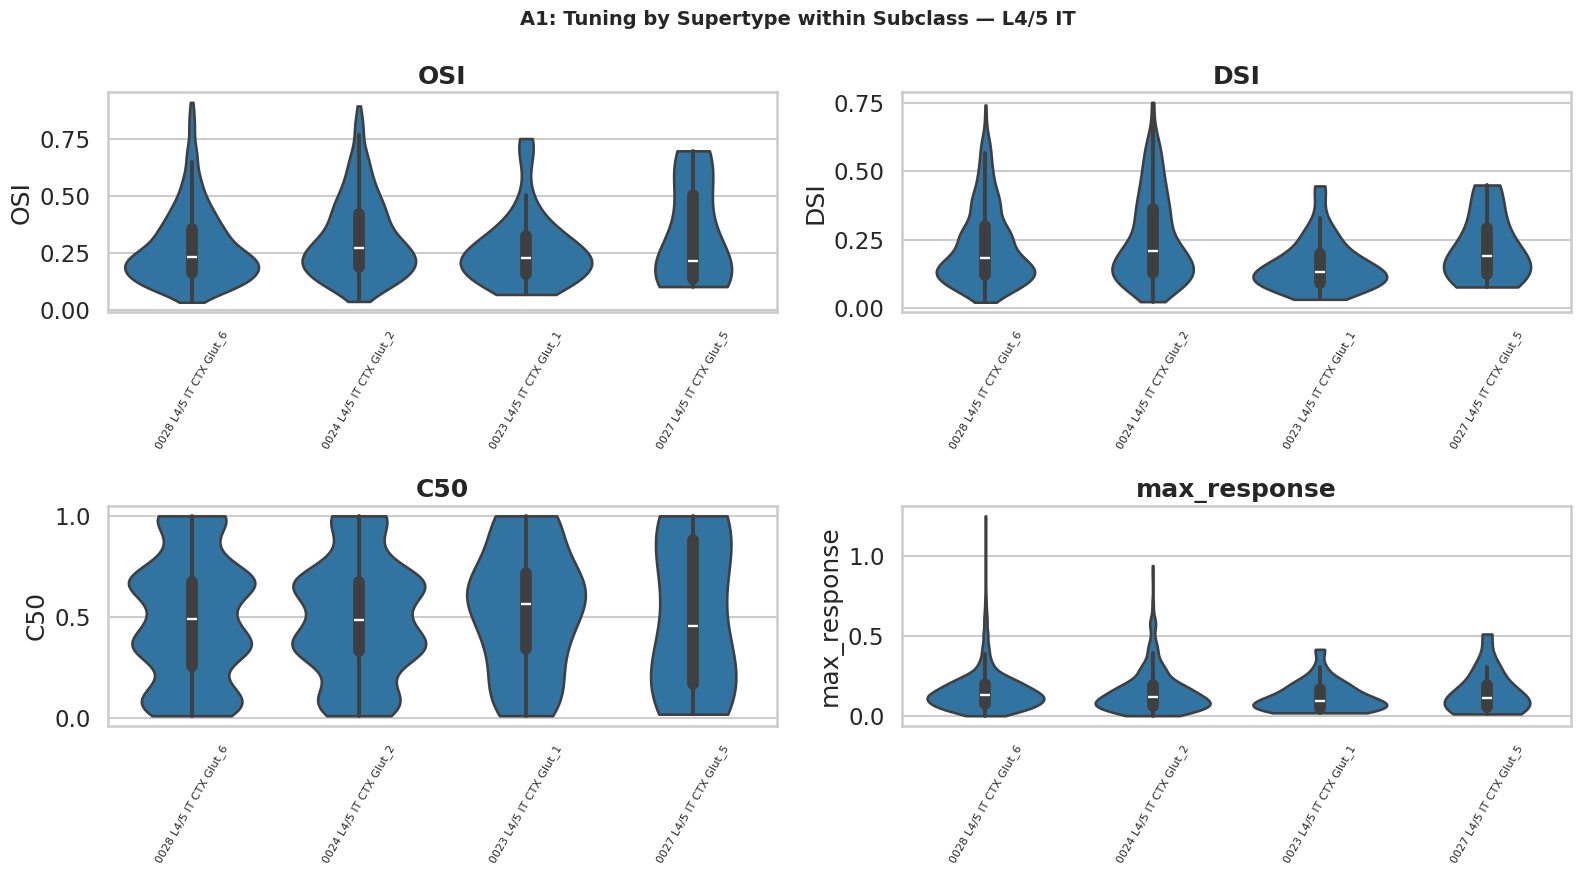

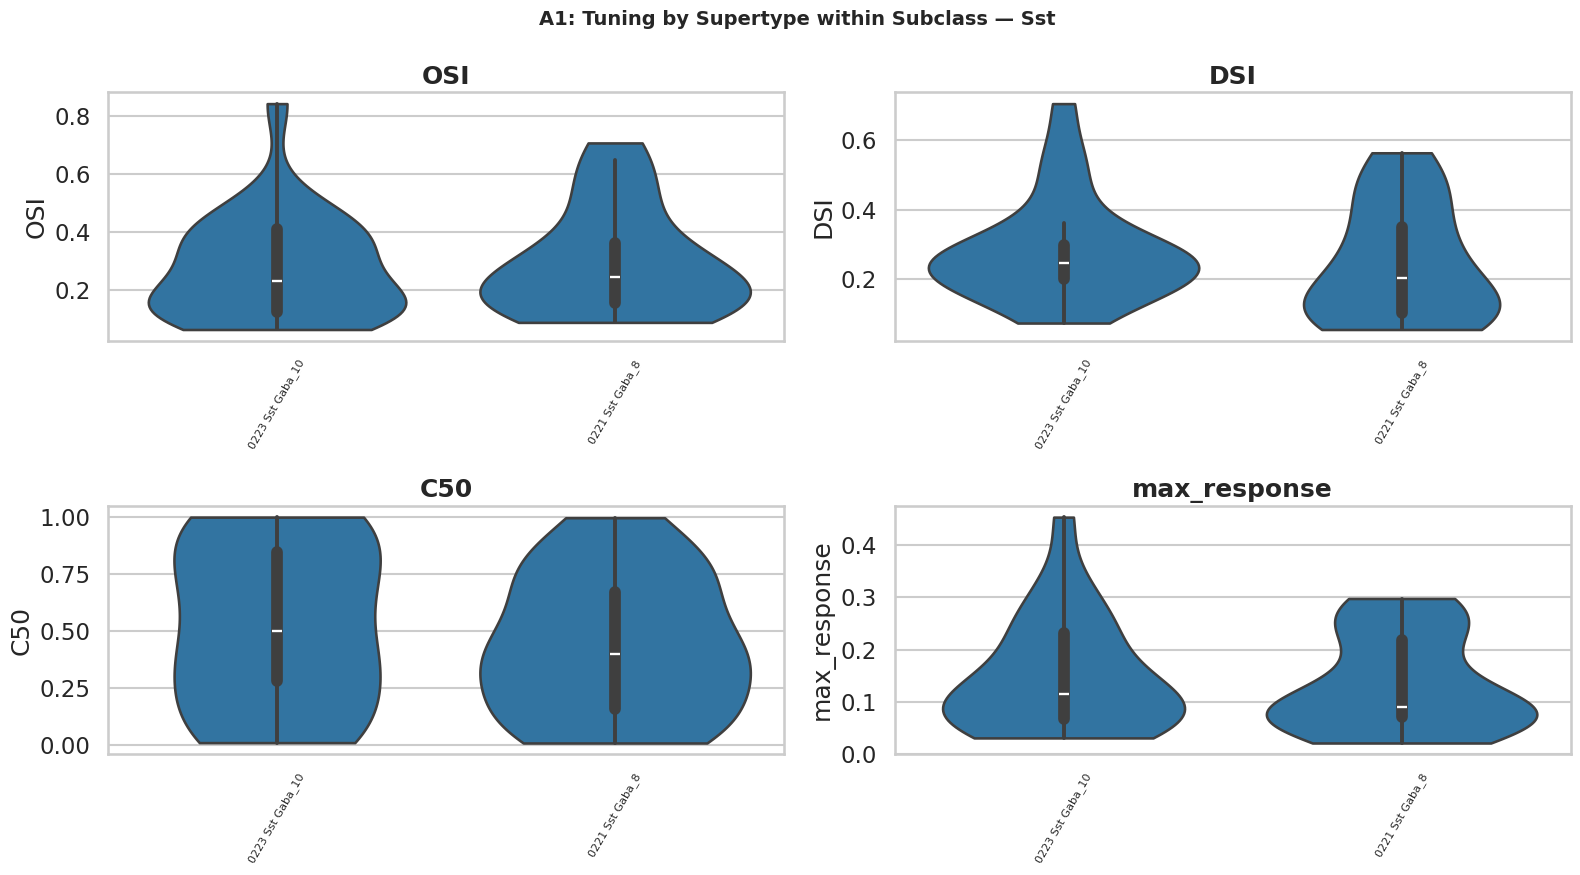

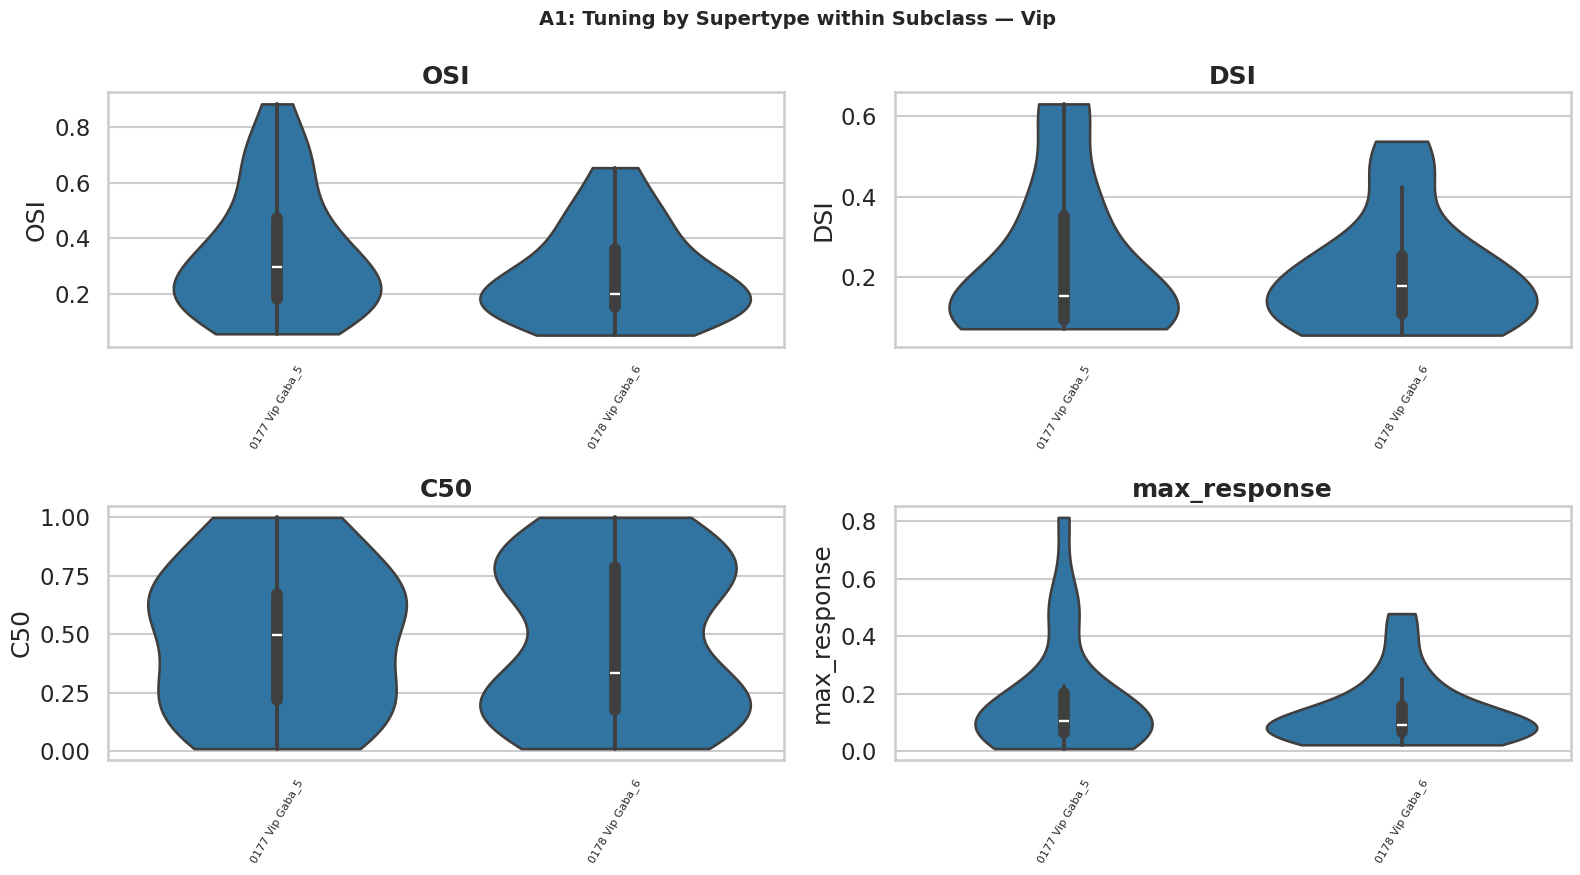

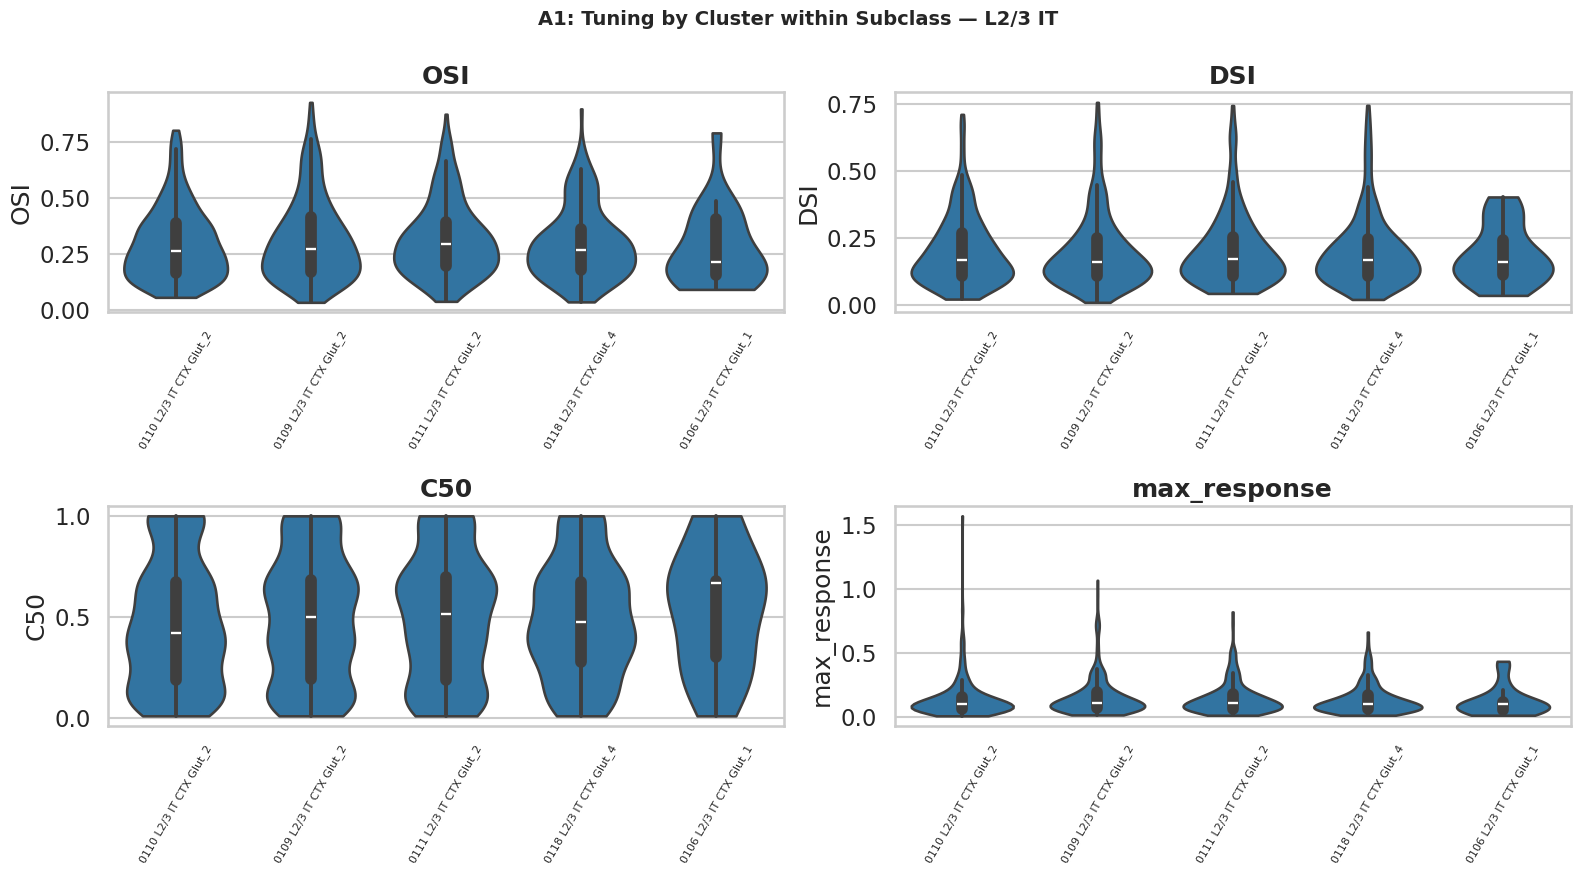

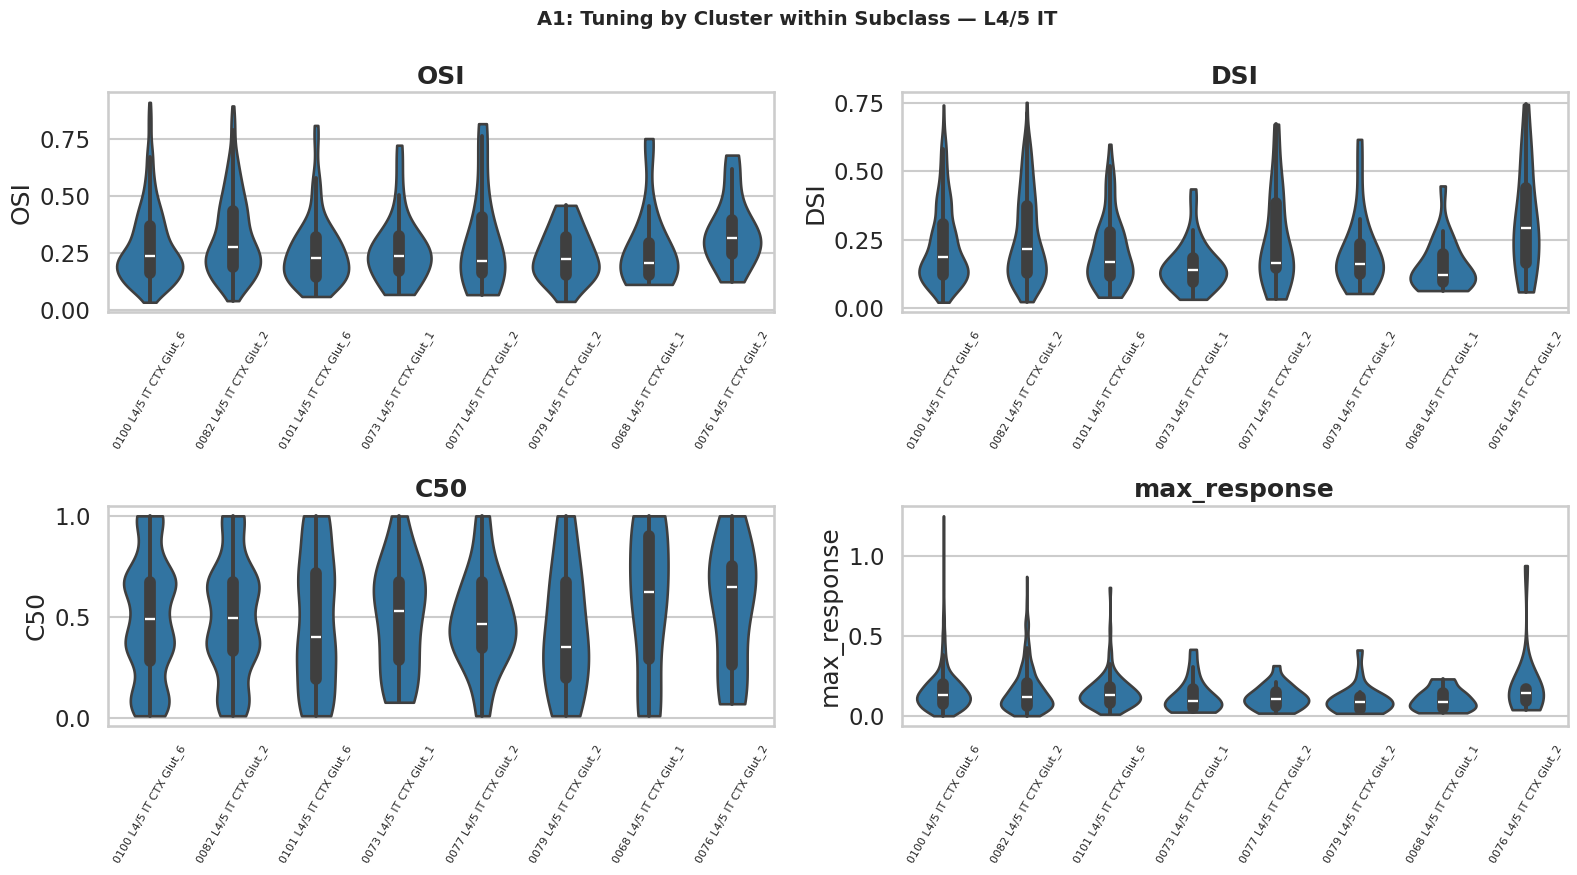

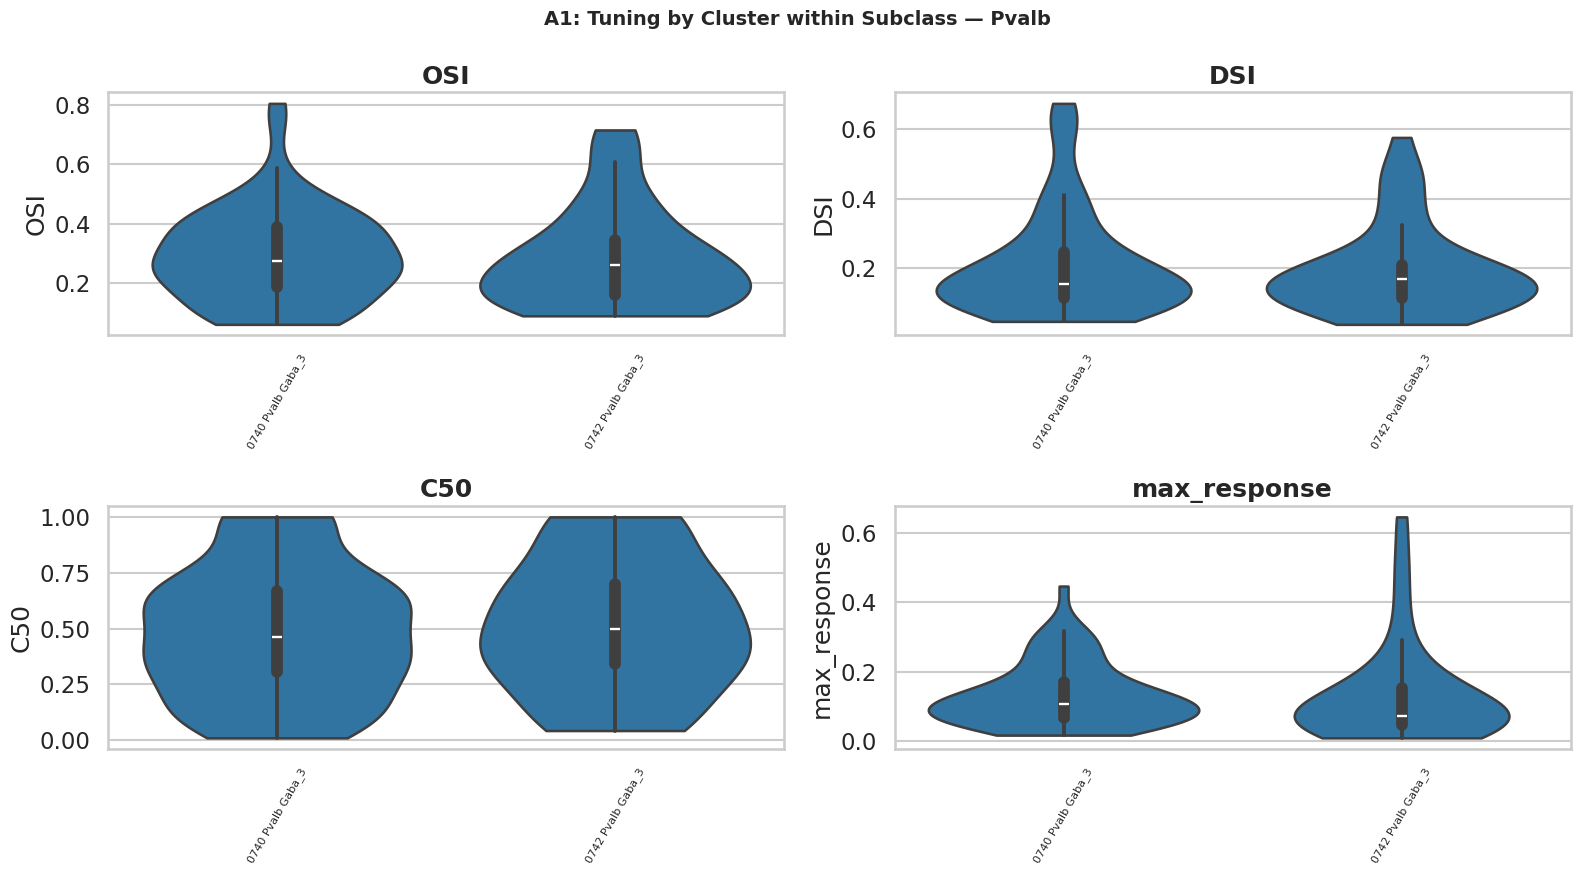

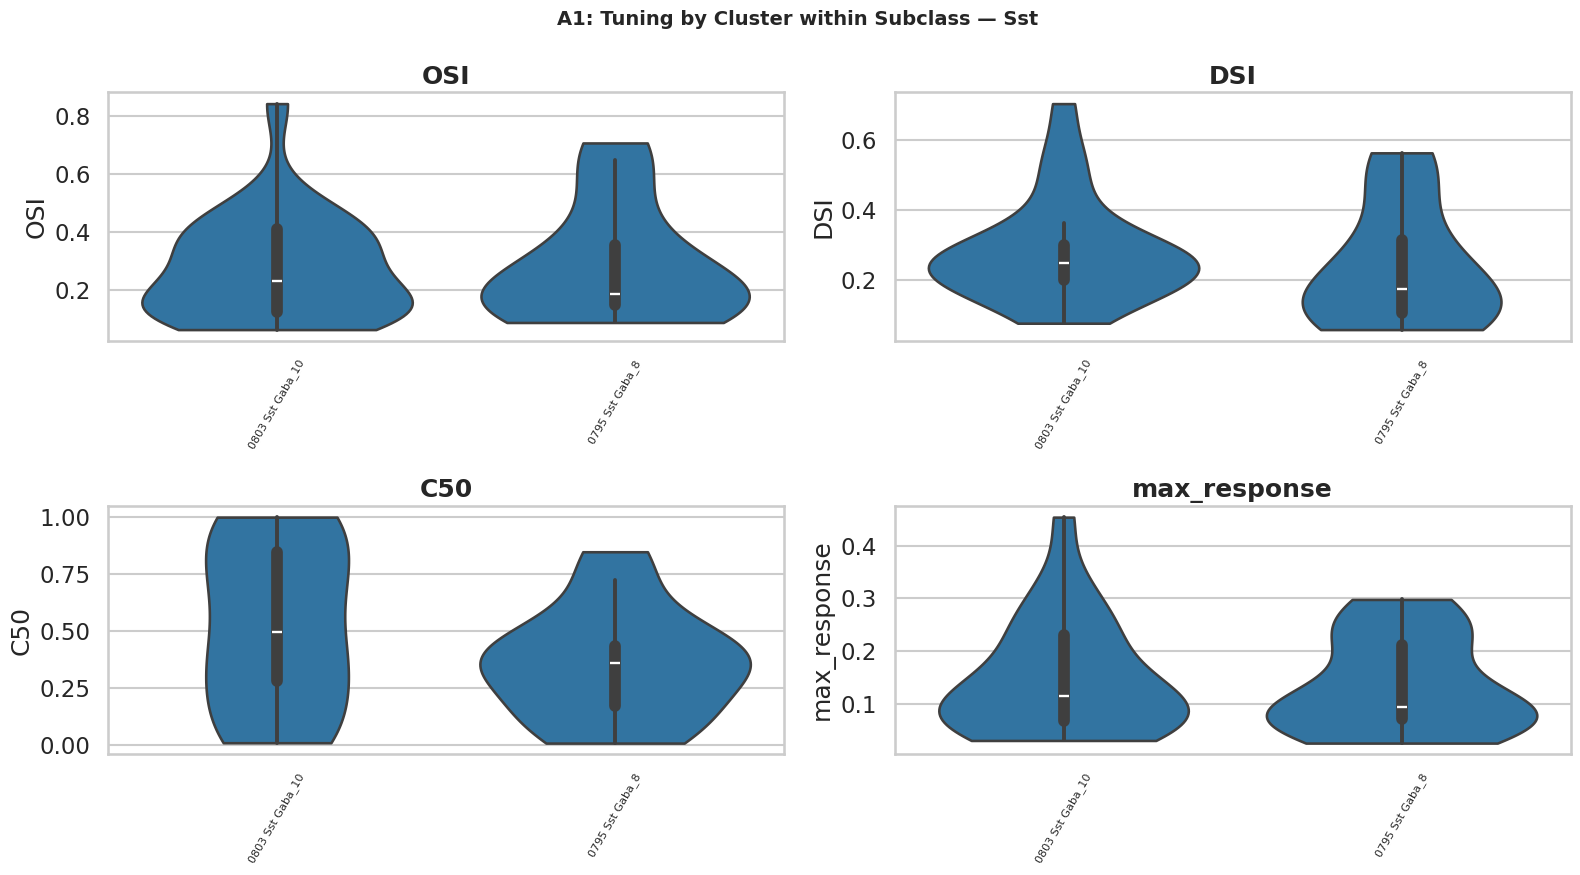

In [25]:
# ══════════════════════════════════════════════════════════════════════
# A1.3b  Nested analyses:
#        (1) supertype within subclass
#        (2) cluster within subclass
# ══════════════════════════════════════════════════════════════════════

def _nested_kruskal(df, parent_col, child_col, metrics, min_cells_per_child=10):
    rows = []
    for parent in present_subclasses:
        d0 = df[df[parent_col] == parent].copy()
        if d0.empty:
            continue

        # keep sufficiently populated child groups
        child_counts = d0[child_col].value_counts()
        keep_children = child_counts[child_counts >= min_cells_per_child].index
        d0 = d0[d0[child_col].isin(keep_children)]

        if d0[child_col].nunique() < 2:
            continue

        for met in metrics:
            groups = [g[met].dropna().values for _, g in d0.groupby(child_col)]
            groups = [g for g in groups if len(g) >= 3]
            if len(groups) < 2:
                continue
            stat, p = kruskal(*groups)
            rows.append({
                'subclass': parent,
                'subclass_short': SUBCLASS_SHORT.get(parent, parent),
                'level': child_col,
                'metric': met,
                'H': stat,
                'p': p,
                'n_groups': d0[child_col].nunique()
            })
    return pd.DataFrame(rows)

# ── Run nested tests ──
nested_supertype = _nested_kruskal(
    tuning_df, parent_col='subclass', child_col='supertype',
    metrics=metrics, min_cells_per_child=10
)
nested_cluster = _nested_kruskal(
    tuning_df, parent_col='subclass', child_col='cluster',
    metrics=metrics, min_cells_per_child=10
)

print("=== Kruskal-Wallis: supertype within subclass ===")
if len(nested_supertype):
    for _, r in nested_supertype.sort_values(['metric', 'p']).iterrows():
        sig = '***' if r['p'] < 0.001 else '**' if r['p'] < 0.01 else '*' if r['p'] < 0.05 else 'ns'
        print(f"  {r['subclass_short']:8s} | {r['metric']:14s}: H={r['H']:8.2f}, p={r['p']:.2e}, groups={int(r['n_groups'])} {sig}")
else:
    print("  No valid tests (insufficient group sizes).")

print("\n=== Kruskal-Wallis: cluster within subclass ===")
if len(nested_cluster):
    for _, r in nested_cluster.sort_values(['metric', 'p']).iterrows():
        sig = '***' if r['p'] < 0.001 else '**' if r['p'] < 0.01 else '*' if r['p'] < 0.05 else 'ns'
        print(f"  {r['subclass_short']:8s} | {r['metric']:14s}: H={r['H']:8.2f}, p={r['p']:.2e}, groups={int(r['n_groups'])} {sig}")
else:
    print("  No valid tests (insufficient group sizes).")

# ── Heatmap summary: -log10(p) ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, res_df, title in [
    (axes[0], nested_supertype, 'Supertype within Subclass'),
    (axes[1], nested_cluster, 'Cluster within Subclass')
]:
    if len(res_df):
        piv = res_df.pivot_table(index='subclass_short', columns='metric', values='p', aggfunc='min')
        sns.heatmap(-np.log10(piv.clip(lower=1e-50)), cmap='magma', ax=ax, annot=True, fmt='.2f')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Metric')
        ax.set_ylabel('Subclass')
    else:
        ax.axis('off')
        ax.set_title(f'{title}\n(no valid tests)', fontweight='bold')

plt.suptitle('A1: Nested Tuning Differences (Kruskal-Wallis)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Violin plots per subclass for nested levels (selected metrics for readability) ──
plot_metrics_nested = ['OSI', 'DSI', 'C50', 'max_response']

def _plot_nested_violins_one_level(df, child_col, title_prefix, min_cells=10, max_children=None):
    for sc in present_subclasses:
        d = df[df['subclass'] == sc].copy()
        counts = d[child_col].value_counts()
        keep = counts[counts >= min_cells].index

        if max_children is not None and len(keep) > max_children:
            keep = counts.loc[keep].sort_values(ascending=False).head(max_children).index

        d = d[d[child_col].isin(keep)]
        if d[child_col].nunique() < 2:
            continue

        fig, axes = plt.subplots(2, 2, figsize=(16, 9))
        for ax, met in zip(axes.flat, plot_metrics_nested):
            sns.violinplot(
                data=d, x=child_col, y=met, order=list(keep),
                cut=0, inner='box', ax=ax
            )
            ax.set_title(met, fontweight='bold')
            ax.tick_params(axis='x', rotation=60, labelsize=8)
            ax.set_xlabel('')

        plt.suptitle(f"{title_prefix} — {SUBCLASS_SHORT.get(sc, sc)}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# supertype plots (usually manageable)
_plot_nested_violins_one_level(
    tuning_df, child_col='supertype',
    title_prefix='A1: Tuning by Supertype within Subclass',
    min_cells=10, max_children=None
)

# cluster plots (limit groups per subclass for readability)
_plot_nested_violins_one_level(
    tuning_df, child_col='cluster',
    title_prefix='A1: Tuning by Cluster within Subclass',
    min_cells=10, max_children=8
)

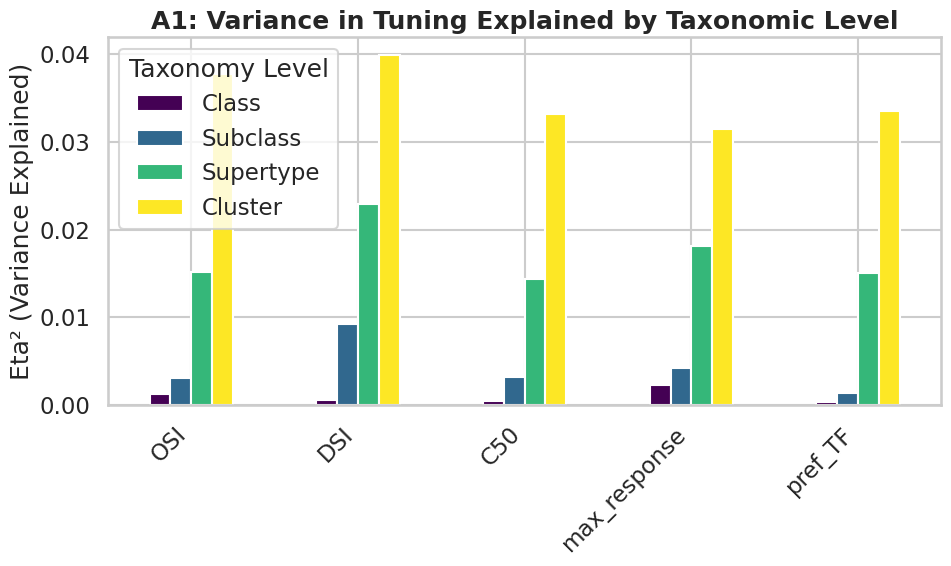

In [26]:
# ══════════════════════════════════════════════════════════════════════
# A1.4  Variance decomposition: how much variance in tuning is explained
#       at each level of the taxonomy? (class → subclass → supertype → cluster)
# ══════════════════════════════════════════════════════════════════════
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

levels = ['class_name', 'subclass_name', 'supertype_name', 'cluster_name']
level_labels = ['Class', 'Subclass', 'Supertype', 'Cluster']

r2_results = {}
for met in ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF']:
    valid = tuning_df[met].notna()
    y = tuning_df.loc[valid, met].values
    r2_per_level = []
    for lvl in levels:
        labels = obs.loc[valid.values, lvl].values if lvl in obs.columns else tuning_df.loc[valid, lvl.replace('_name', '')].values
        le = LabelEncoder()
        groups = le.fit_transform(labels)
        # R² from group means (eta-squared)
        group_means = np.array([np.mean(y[groups == g]) for g in range(len(le.classes_))])
        y_pred = group_means[groups]
        ss_between = np.sum((y_pred - np.mean(y))**2)
        ss_total = np.sum((y - np.mean(y))**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        r2_per_level.append(eta2)
    r2_results[met] = r2_per_level

# ── Visualization: Stacked bar of variance explained ──
r2_df = pd.DataFrame(r2_results, index=level_labels)
fig, ax = plt.subplots(figsize=(10, 6))
r2_df.T.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Eta² (Variance Explained)')
ax.set_title('A1: Variance in Tuning Explained by Taxonomic Level', fontweight='bold')
ax.legend(title='Taxonomy Level')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()



Subclass prediction from tuning (Leave-One-Mouse-Out LDA): accuracy = 0.484


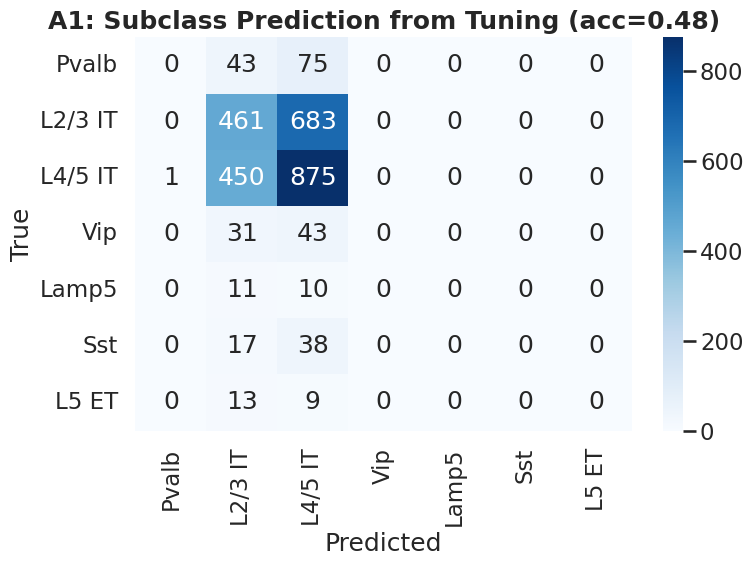

In [27]:

# ── Confusion matrix: predict subclass from tuning ──
feature_cols = ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF', 'TF_lowpass_idx']
valid = tuning_df[feature_cols].notna().all(axis=1)
X_feat = tuning_df.loc[valid, feature_cols].values
y_label = tuning_df.loc[valid, 'subclass'].values

# Only subclasses with enough cells
from collections import Counter
counts = Counter(y_label)
keep = [k for k, v in counts.items() if v >= 10]
mask_keep = np.isin(y_label, keep)
X_feat_k, y_label_k = X_feat[mask_keep], y_label[mask_keep]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat_k)

# Leave-one-mouse-out cross-validation
mouse_ids = tuning_df.loc[valid, 'mouse_id'].values[mask_keep]
logo = LeaveOneGroupOut()
y_pred_all, y_true_all = [], []
for train_idx, test_idx in logo.split(X_scaled, y_label_k, groups=mouse_ids):
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_scaled[train_idx], y_label_k[train_idx])
    y_pred_all.extend(clf.predict(X_scaled[test_idx]))
    y_true_all.extend(y_label_k[test_idx])

acc = accuracy_score(y_true_all, y_pred_all)
print(f"\nSubclass prediction from tuning (Leave-One-Mouse-Out LDA): accuracy = {acc:.3f}")

cm = confusion_matrix(y_true_all, y_pred_all, labels=keep)
short_labels = [SUBCLASS_SHORT.get(k, k) for k in keep]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=short_labels, yticklabels=short_labels,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'A1: Subclass Prediction from Tuning (acc={acc:.2f})', fontweight='bold')
plt.tight_layout()
plt.show()

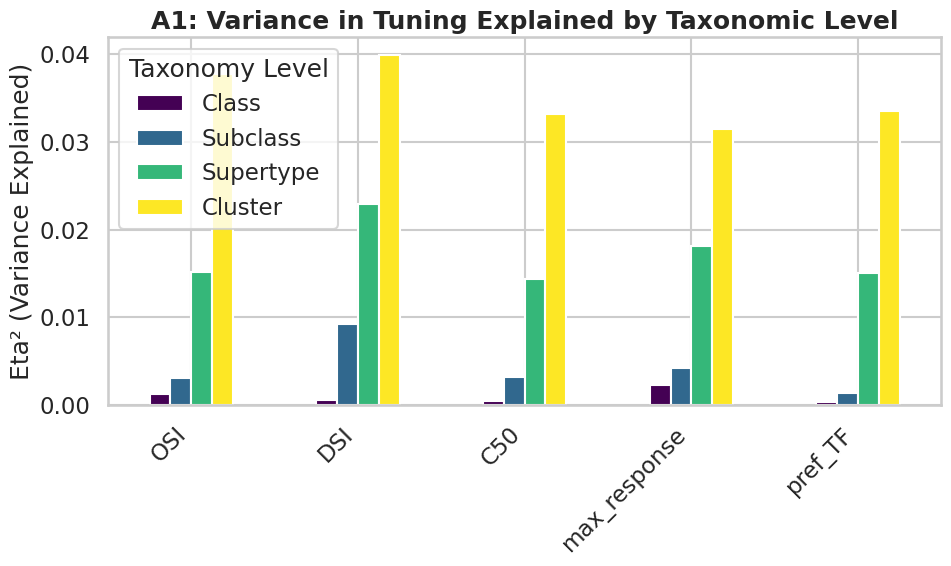


Subclass prediction from tuning (Leave-One-Mouse-Out LDA): accuracy = 0.484


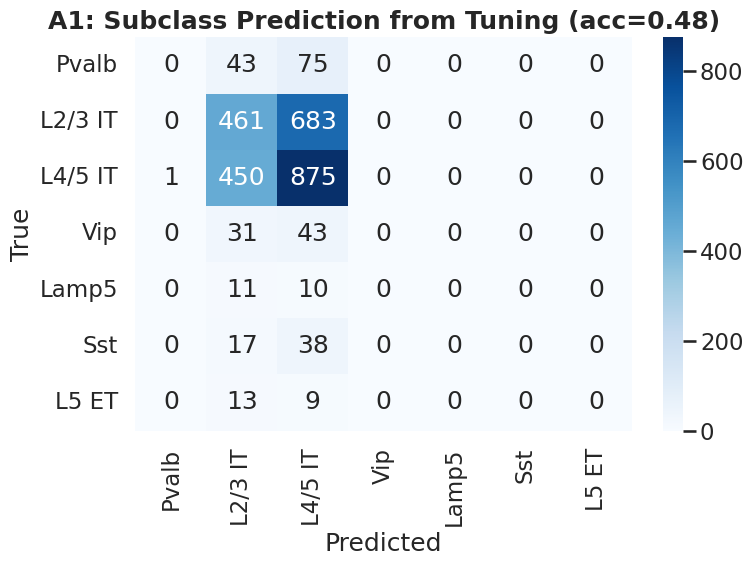

In [28]:
# ══════════════════════════════════════════════════════════════════════
# A1.4  Variance decomposition: how much variance in tuning is explained
#       at each level of the taxonomy? (class → subclass → supertype → cluster)
# ══════════════════════════════════════════════════════════════════════
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder

levels = ['class_name', 'subclass_name', 'supertype_name', 'cluster_name']
level_labels = ['Class', 'Subclass', 'Supertype', 'Cluster']

r2_results = {}
for met in ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF']:
    valid = tuning_df[met].notna()
    y = tuning_df.loc[valid, met].values
    r2_per_level = []
    for lvl in levels:
        labels = obs.loc[valid.values, lvl].values if lvl in obs.columns else tuning_df.loc[valid, lvl.replace('_name', '')].values
        le = LabelEncoder()
        groups = le.fit_transform(labels)
        # R² from group means (eta-squared)
        group_means = np.array([np.mean(y[groups == g]) for g in range(len(le.classes_))])
        y_pred = group_means[groups]
        ss_between = np.sum((y_pred - np.mean(y))**2)
        ss_total = np.sum((y - np.mean(y))**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        r2_per_level.append(eta2)
    r2_results[met] = r2_per_level

# ── Visualization: Stacked bar of variance explained ──
r2_df = pd.DataFrame(r2_results, index=level_labels)
fig, ax = plt.subplots(figsize=(10, 6))
r2_df.T.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Eta² (Variance Explained)')
ax.set_title('A1: Variance in Tuning Explained by Taxonomic Level', fontweight='bold')
ax.legend(title='Taxonomy Level')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Confusion matrix: predict subclass from tuning ──
feature_cols = ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF', 'TF_lowpass_idx']
valid = tuning_df[feature_cols].notna().all(axis=1)
X_feat = tuning_df.loc[valid, feature_cols].values
y_label = tuning_df.loc[valid, 'subclass'].values

# Only subclasses with enough cells
from collections import Counter
counts = Counter(y_label)
keep = [k for k, v in counts.items() if v >= 10]
mask_keep = np.isin(y_label, keep)
X_feat_k, y_label_k = X_feat[mask_keep], y_label[mask_keep]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat_k)

# Leave-one-mouse-out cross-validation
mouse_ids = tuning_df.loc[valid, 'mouse_id'].values[mask_keep]
logo = LeaveOneGroupOut()
y_pred_all, y_true_all = [], []
for train_idx, test_idx in logo.split(X_scaled, y_label_k, groups=mouse_ids):
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_scaled[train_idx], y_label_k[train_idx])
    y_pred_all.extend(clf.predict(X_scaled[test_idx]))
    y_true_all.extend(y_label_k[test_idx])

acc = accuracy_score(y_true_all, y_pred_all)
print(f"\nSubclass prediction from tuning (Leave-One-Mouse-Out LDA): accuracy = {acc:.3f}")

cm = confusion_matrix(y_true_all, y_pred_all, labels=keep)
short_labels = [SUBCLASS_SHORT.get(k, k) for k in keep]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=short_labels, yticklabels=short_labels,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'A1: Subclass Prediction from Tuning (acc={acc:.2f})', fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# ══════════════════════════════════════════════════════════════════════
# A1.5  Post-hoc pairwise comparisons (Dunn's test) + hierarchical
#       clustering dendrogram of cells by tuning vectors
# ══════════════════════════════════════════════════════════════════════
from itertools import combinations
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# ── Dunn-style pairwise Mann-Whitney U with Bonferroni correction ──
print("=== Pairwise Mann-Whitney U (Bonferroni-corrected) ===\n")
for met in ['OSI', 'DSI', 'C50', 'max_response']:
    print(f"--- {met} ---")
    pairs = list(combinations(present_subclasses, 2))
    n_pairs = len(pairs)
    for s1, s2 in pairs:
        g1 = tuning_df.loc[tuning_df['subclass'] == s1, met].dropna()
        g2 = tuning_df.loc[tuning_df['subclass'] == s2, met].dropna()
        if len(g1) < 3 or len(g2) < 3:
            continue
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        p_adj = min(p * n_pairs, 1.0)  # Bonferroni
        sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
        if p_adj < 0.05:
            print(f"  {SUBCLASS_SHORT[s1]:8s} vs {SUBCLASS_SHORT[s2]:8s}: U={stat:.0f}, p_adj={p_adj:.2e} {sig}")
    print()

# ── Hierarchical clustering dendrogram based on tuning vectors ──
# Build a tuning feature vector per cell: [ori_responses (8), crf_responses (5), tf_responses (5)]
tuning_vectors = np.hstack([ori_responses_all, crf_responses_all, tf_responses_all])  # n_cells x 18
valid_cells = ~np.isnan(tuning_vectors).any(axis=1) & (np.std(tuning_vectors, axis=1) > 1e-6)
tv_clean = tuning_vectors[valid_cells]
tv_labels = obs['subclass_name'].values[valid_cells]
n_show = min(500, tv_clean.shape[0])  # subsample for readability

rng = np.random.default_rng(42)
idx = rng.choice(tv_clean.shape[0], size=n_show, replace=False)
tv_sub = tv_clean[idx]
labels_sub = tv_labels[idx]

# Z-score each feature
tv_sub_z = (tv_sub - tv_sub.mean(axis=0)) / (tv_sub.std(axis=0) + 1e-8)

Z = linkage(tv_sub_z, method='ward', metric='euclidean')
label_colors = {s: SUBCLASS_COLORS[s] for s in present_subclasses}
leaf_colors = [label_colors.get(labels_sub[i], '#333333') for i in range(n_show)]

fig, ax = plt.subplots(figsize=(18, 6))
dn = dendrogram(Z, ax=ax, no_labels=True, color_threshold=0, above_threshold_color='gray')
# Color leaves
xlbls = ax.get_xticklabels()
leaves = dn['leaves']
for i, leaf_idx in enumerate(leaves):
    x = 5 + 10 * i
    ax.plot(x, 0, 'o', color=leaf_colors[leaf_idx], markersize=2)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=SUBCLASS_COLORS[s], label=SUBCLASS_SHORT[s])
                   for s in present_subclasses]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, ncol=2)
ax.set_title('A1: Hierarchical Clustering of Cells by Tuning Vectors (Ward)', fontweight='bold')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

=== Pairwise Mann-Whitney U (Bonferroni-corrected) ===

--- OSI ---

--- DSI ---
  L2/3 IT  vs L4/5 IT : U=700636, p_adj=6.56e-06 ***

--- C50 ---

--- max_response ---
  L2/3 IT  vs L4/5 IT : U=710551, p_adj=1.01e-04 ***



NameError: name 'ori_responses_all' is not defined